# Классификация ориентации текстовых кропов: $0^\circ$ / $180^\circ$

## Цель

Требуется для каждого текстового crop предсказать вероятность \(p_{180}\) того, что
текст расположен в ориентации \(180^\circ\), то есть перевёрнут относительно
нормальной горизонтальной ориентации.

Итоговый файл `submission.csv` содержит две колонки:

- `image_id` — идентификатор изображения;
- `p_180` — вероятность поворота текста на \(180^\circ\).

## Краткое резюме решения

В работе были реализованы и сравнены два направления:

1. собственные компактные CNN-классификаторы, обученные на сочетании реальных
   OCR-кропов и синтетических русско-английских текстовых изображений;
2. специализированный открытый классификатор ориентации текстовых строк
   `PP-LCNet_x0_25_textline_ori` из экосистемы PaddleOCR/PaddleX.

По результатам независимой validation-выборки в качестве основной модели выбран
PaddleOCR orientation classifier. Дополнительный анализ preprocessing показал,
что мягкое усиление локального контраста методом CLAHE улучшает вероятностное
качество по Brier score по сравнению с исходным изображением.

Финальный pipeline:


$\text{RGB crop}
\rightarrow
\text{CLAHE по L-каналу в пространстве LAB}
\rightarrow
\text{PaddleOCR text-line orientation classifier}
\rightarrow
p_{180}
\rightarrow
\texttt{submission.csv}.
$

## 0. Окружение и воспроизводимость

In [1]:
import os
import sys
import json
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("opencv:", cv2.__version__)

Python: 3.12.13 (main, Jul 18 2026, 16:55:18) [Clang 22.1.3 ]
numpy: 2.3.5
pandas: 3.0.6
opencv: 5.0.0


In [2]:
PROJECT_ROOT = Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data"
TEST_ROOT = DATA_DIR / "test" 
TEST_DIR = TEST_ROOT / "images"  
EXTERNAL_DIR = DATA_DIR / "external"
SYNTH_DIR = DATA_DIR / "synthetic_ru"
PROCESSED_DIR = DATA_DIR / "processed"
SPLITS_DIR = DATA_DIR / "splits"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

for d in [
    DATA_DIR,
    TEST_ROOT,
    TEST_DIR,
    EXTERNAL_DIR,
    SYNTH_DIR,
    PROCESSED_DIR,
    SPLITS_DIR,
    OUTPUTS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)



## 1. Аудит тестовых данных

Оцениваются только на технические свойстваё входа (размеры, aspect ratio, число каналов,
резкость/шум) — это определяет препроцессинг (resize/padding, целевое разрешение) и то,
какие аугментации имеет смысл добавить в синтетику, чтобы она была похожа на тест по "качеству
картинки". Разметку ориентации теста мы не создаём и не смотрим на неё вообще — в файлах её и
нет, поэтому утечки в принципе быть не может.

Перед запуском: скачайте архив по ссылке из задания и распакуйте кропы в `data/test/`.


In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

test_files = sorted([p for p in TEST_DIR.rglob("*") if p.suffix.lower() in IMG_EXTS])
print(f"Найдено файлов в data/test: {len(test_files)}")


Найдено файлов в data/test: 20000


In [4]:
image_ids = [p.stem for p in test_files]
n_total = len(image_ids)
n_unique = len(set(image_ids))
print(f"Всего файлов: {n_total}, уникальных image_id: {n_unique}")

sample_sub_path = DATA_DIR / "sample_submission.csv"
if sample_sub_path.exists():
    sample_sub = pd.read_csv(sample_sub_path)
    print(sample_sub.head())
    print("Колонки:", list(sample_sub.columns))
    missing = set(sample_sub["image_id"]) - set(image_ids)
    extra = set(image_ids) - set(sample_sub["image_id"])
    print(f"В sample_submission, но нет файла: {len(missing)}")
    print(f"Есть файл, но нет в sample_submission: {len(extra)}")

Всего файлов: 20000, уникальных image_id: 20000
     image_id  p_180
0  test_00000    0.5
1  test_00001    0.5
2  test_00002    0.5
3  test_00003    0.5
4  test_00004    0.5
Колонки: ['image_id', 'p_180']
В sample_submission, но нет файла: 0
Есть файл, но нет в sample_submission: 0


In [11]:
def probe_image(path: Path) -> dict:
    try:
        with Image.open(path) as im:
            w, h = im.size
            mode = im.mode
        file_size_kb = path.stat().st_size / 1024
        return {
            "image_id": path.name,
            "width": w,
            "height": h,
            "aspect_ratio": w / max(h, 1),
            "mode": mode,
            "file_size_kb": file_size_kb,
            "readable": True,
        }
    except Exception as e:
        return {"image_id": path.name, "readable": False, "error": str(e)}

if test_files:
    records = [probe_image(p) for p in test_files]
    audit_df = pd.DataFrame(records)

    n_bad = (~audit_df["readable"]).sum()
    print(f"Нечитаемых/битых файлов: {n_bad}")
    if n_bad:
        print(audit_df[~audit_df["readable"]].head(20))

    ok = audit_df[audit_df["readable"]].copy()
    print("\nРаспределение режимов (channels):")
    print(ok["mode"].value_counts())

    print("\nСтатистика по размерам:")
    print(ok[["width", "height", "aspect_ratio", "file_size_kb"]].describe(
        percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
    ))

    tiny = ok[(ok["height"] < 16) | (ok["width"] < 16)]
    print(f"\nДоля кропов с высотой или шириной < 16px: {len(tiny) / len(ok):.2%}")

    very_wide = ok[ok["aspect_ratio"] > 8]
    print(f"Доля очень длинных/узких кропов (aspect_ratio > 8): {len(very_wide) / len(ok):.2%}")

    audit_df.to_csv(OUTPUTS_DIR / "test_audit.csv", index=False)
    print("\nСохранено: outputs/test_audit.csv")
else:
    audit_df = pd.DataFrame()


Нечитаемых/битых файлов: 0

Распределение режимов (channels):
mode
RGB    20000
Name: count, dtype: int64

Статистика по размерам:
              width        height  aspect_ratio  file_size_kb
count  20000.000000  20000.000000  20000.000000  20000.000000
mean     357.603600     64.398150      6.220858     33.133346
std      318.933591     59.337019      4.267151     54.021982
min       25.000000     10.000000      0.720930      0.568359
1%        40.000000     12.000000      1.761886      1.434541
5%        61.000000     16.000000      2.319909      2.358350
50%      238.000000     42.000000      4.894899     13.183105
95%     1047.000000    195.000000     14.447785    135.447803
99%     1406.000000    289.000000     22.609812    253.621221
max     1599.000000    492.000000     49.666667   1082.954102

Доля кропов с высотой или шириной < 16px: 4.76%
Доля очень длинных/узких кропов (aspect_ratio > 8): 22.07%

Сохранено: outputs/test_audit.csv


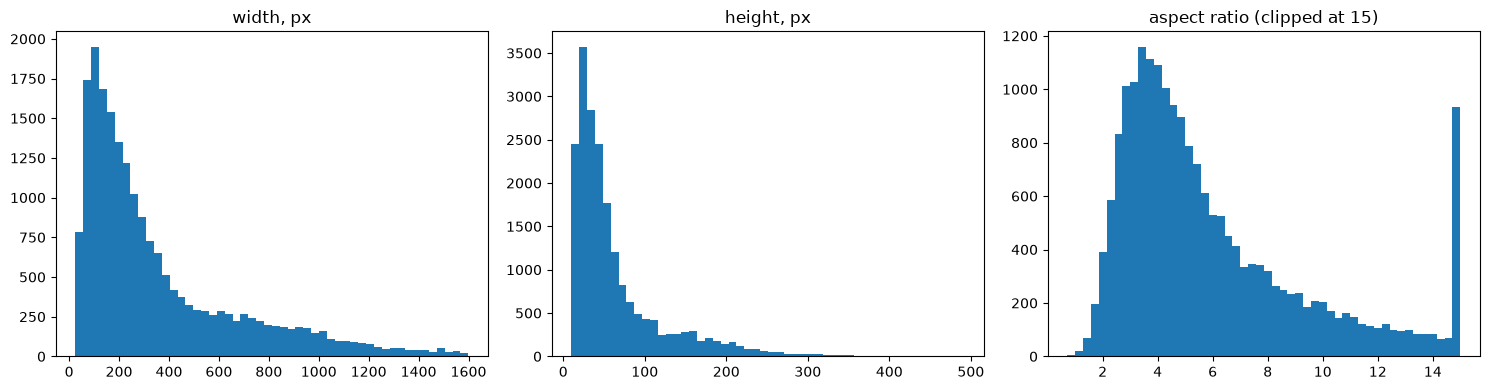

In [12]:
if len(test_files):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(ok["width"], bins=50)
    axes[0].set_title("width, px")
    axes[1].hist(ok["height"], bins=50)
    axes[1].set_title("height, px")
    axes[2].hist(ok["aspect_ratio"].clip(upper=15), bins=50)
    axes[2].set_title("aspect ratio (clipped at 15)")
    plt.tight_layout()
    fig.savefig(OUTPUTS_DIR / "figures_test_size_hist.png", dpi=120)
    plt.show()


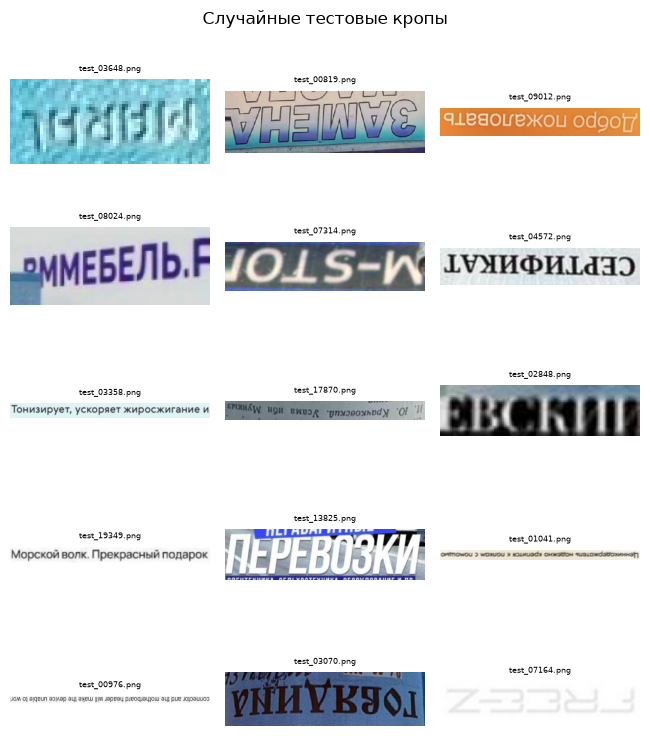

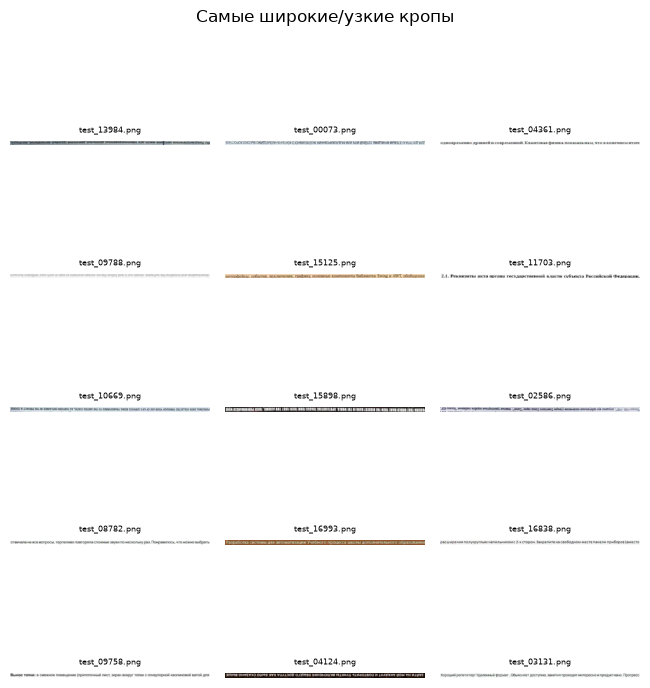

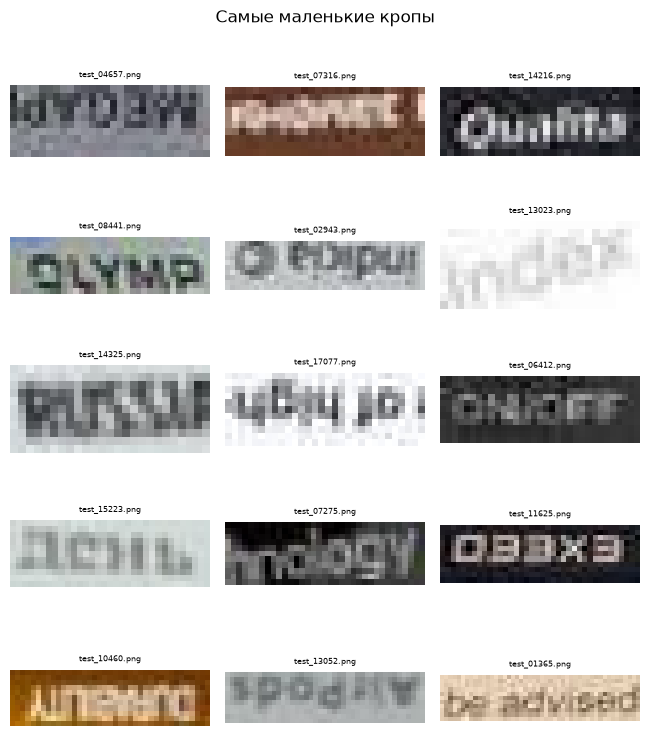

In [13]:
def show_montage(paths, title, n=15, cols=3):
    paths = paths[:n]
    rows = int(np.ceil(len(paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 1.6))
    axes = np.array(axes).reshape(-1)
    for ax, p in zip(axes, paths):
        img = cv2.imread(str(p))
        if img is not None:
            ax.imshow(img)
        ax.set_title(p.name, fontsize=6)
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    return fig

if len(test_files):
    rng = random.Random(SEED)

    random_sample = [TEST_DIR / n for n in rng.sample(list(ok["image_id"]), min(15, len(ok)))]
    fig1 = show_montage(random_sample, "Случайные тестовые кропы")
    fig1.savefig(OUTPUTS_DIR / "figures_montage_random.png", dpi=300)

    wide_ids = ok.sort_values("aspect_ratio", ascending=False)["image_id"].head(15).tolist()
    fig2 = show_montage([TEST_DIR / n for n in wide_ids], "Самые широкие/узкие кропы")
    fig2.savefig(OUTPUTS_DIR / "figures_montage_wide.png", dpi=300)

    small_ids = ok.sort_values(["height", "width"]).head(15)["image_id"].tolist()
    fig3 = show_montage([TEST_DIR / n for n in small_ids], "Самые маленькие кропы")
    fig3.savefig(OUTPUTS_DIR / "figures_montage_small.png", dpi=300)

    plt.show()


### 1.1. Выводы аудита и их влияние на pipeline

Тестовая выборка содержит 20 000 изображений. Все файлы успешно считываются,
имеют цветовой режим RGB и уникальные идентификаторы, полностью совпадающие с
`sample_submission.csv`. Следовательно, на этапе preprocessing не требуется
отдельная обработка grayscale- или RGBA-изображений тестовой выборки, однако
функция загрузки всё равно приводит вход к RGB для универсальности pipeline.

Размеры текстовых кропов существенно неоднородны. Медианная ширина составляет
238 px, медианная высота — 42 px, а медианное соотношение сторон — 4.89.
При этом 95% кропов имеют ширину не более 1047 px и высоту не более 195 px.
Около 22.07% изображений имеют aspect ratio более 8, а максимальное
соотношение сторон достигает 49.67. Поэтому квадратный вход и жёсткое
масштабирование изображений к фиксированному размеру без сохранения пропорций
могут существенно исказить геометрию текста.

Для моделей используется прямоугольный вход размера `64 × 256` с сохранением
aspect ratio: изображение масштабируется по высоте до 64 px, после чего при
необходимости сжимается по ширине до 256 px и дополняется padding. Такое
представление соответствует преимущественно горизонтальному характеру
тестовых кропов и ограничивает вычислительную стоимость инференса.

Около 4.76% кропов имеют хотя бы одну сторону менее 16 px. Такие изображения
содержат мало визуальной информации и чувствительны к JPEG-артефактам,
размытию и шуму. Поэтому при обучении используются умеренные аугментации
качества: JPEG/WebP-compression, downscale-upscale, Gaussian noise и blur.
При этом аугментации не применяются к validation- и test-изображениям.

Важно: тестовая выборка использовалась исключительно для аудита технических
свойств входных данных — числа файлов, размеров, соотношений сторон, цветовых
режимов и формата идентификаторов. Ручные метки ориентации не создавались и не
использовались для обучения, выбора архитектуры, подбора аугментаций,
калибровки вероятностей или оценки качества моделей.

## 2. Формирование обучающей выборки

Поскольку обучающая разметка в исходной задаче не предоставляется, обучающая
выборка сформирована из двух источников:

1. **Реальные текстовые кропы COCO-Text** — используются как источник
   естественных изображений с фонами, вариациями освещения, шумом и артефактами
   выделения текстовых регионов.
2. **Синтетические русско-английские текстовые кропы** — добавляют кириллицу,
   типичные для объявлений строки, цены, номера телефонов, адреса, бренды,
   шрифтовое разнообразие и геометрию, близкую к тестовой выборке.

Все базовые изображения хранятся в канонической upright-ориентации.
Целевая метка $y \in \{0,1\}$ формируется автоматически: для класса $y=1$
изображение поворачивается на $180^\circ$. Такой подход не требует ручной
разметки и обеспечивает точное знание целевой переменной.

### 2.1. Реальные текстовые кропы: извлечение из COCO-Text

Изображения COCO-Text извлекаются по предоставленной YOLO-разметке. К bounding
box добавляется небольшой контекстный padding, после чего crop сохраняется вместе
с метаданными: идентификатором исходного изображения, координатами, размером и
путём к файлу.

Минимальный размер стороны crop ограничивается, чтобы исключить почти
неинформативные фрагменты. После визуального контроля и сопоставления геометрии
с тестовой выборкой применяется дополнительная фильтрация: в последующее
обучение включаются только кропы с геометрией, наиболее близкой к test-domain.

In [14]:
# Раскладка:
#   data/external/coco_text/data/*.jpg   -- изображения
#   data/external/coco_text/data/*.txt   -- YOLO-разметка (class xc yc w h, нормированные)

COCO_TEXT_DIR = EXTERNAL_DIR / "coco_text"
COCO_TEXT_IMG_DIR = COCO_TEXT_DIR / "data"  

CROPS_DIR = PROCESSED_DIR / "coco_text_crops"
CROPS_DIR.mkdir(parents=True, exist_ok=True)

MIN_CROP_SIDE = 8  # отбрасываем слишком маленькие боксы
MAX_CROPS_TOTAL = 100_000  # лимит на объём
PAD_FRAC = 0.05  # небольшой паддинг вокруг bbox


def load_yolo_classes(path: Path):
    """Читает classes.txt -> {class_id: class_name}. Если файла нет, вернёт {}."""
    if not path.exists():
        return {}
    names = [
        ln.strip() for ln in path.read_text(encoding="utf-8").splitlines() if ln.strip()
    ]
    return {i: n for i, n in enumerate(names)}


def read_yolo_labels(txt_path: Path):
    """Возвращает список (class_id, xc, yc, w, h) в нормированных координатах."""
    rows = []
    for ln in txt_path.read_text(encoding="utf-8").splitlines():
        ln = ln.strip()
        if not ln:
            continue
        parts = ln.split()
        if len(parts) < 5:
            continue
        try:
            cls = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
        except ValueError:
            continue
        rows.append((cls, xc, yc, w, h))
    return rows


def extract_coco_text_crops(
    img_dir: Path,
    out_dir: Path,
    classes_path: Path | None = None,
    max_crops: int = MAX_CROPS_TOTAL,
) -> pd.DataFrame:
    """Извлекает текстовые кропы из COCO-Text по YOLO-разметке.

    Для каждого .jpg рядом ищется .txt с боксами. Координаты нормированные,
    конвертируются в пиксельные, добавляется небольшой паддинг, кроп сохраняется.
    """
    empty_cols = [
        "crop_id",
        "source",
        "source_image_id",
        "image_path",
        "crop_path",
        "x1",
        "y1",
        "x2",
        "y2",
        "width",
        "height",
        "class_id",
        "class_name",
        "is_synthetic",
    ]

    if not img_dir.exists():
        print(f"[skip] Нет папки {img_dir} — положи COCO-Text туда.")
        return pd.DataFrame(columns=empty_cols)

    class_map = load_yolo_classes(classes_path) if classes_path else {}

    img_paths = sorted(
        [
            p
            for p in img_dir.iterdir()
            if p.is_file()
            and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        ]
    )
    print(f"COCO-Text: найдено изображений: {len(img_paths)}")

    records = []
    n_saved = 0
    n_skipped_no_label = 0
    n_skipped_unreadable = 0

    for img_path in img_paths:
        if n_saved >= max_crops:
            break

        txt_path = img_path.with_suffix(".txt")
        if not txt_path.exists():
            n_skipped_no_label += 1
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            n_skipped_unreadable += 1
            continue
        H, W = img.shape[:2]

        for i, (cls, xc, yc, w, h) in enumerate(read_yolo_labels(txt_path)):
            if n_saved >= max_crops:
                break

            # нормированные -> пиксельные
            bw, bh = w * W, h * H
            if bw < MIN_CROP_SIDE or bh < MIN_CROP_SIDE:
                continue

            cx, cy = xc * W, yc * H
            pad_w, pad_h = bw * PAD_FRAC, bh * PAD_FRAC

            x1 = max(0, int(round(cx - bw / 2 - pad_w)))
            y1 = max(0, int(round(cy - bh / 2 - pad_h)))
            x2 = min(W, int(round(cx + bw / 2 + pad_w)))
            y2 = min(H, int(round(cy + bh / 2 + pad_h)))
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img[y1:y2, x1:x2]
            crop_id = f"coco_{img_path.stem}_{i:04d}"
            crop_path = out_dir / f"{crop_id}.jpg"
            cv2.imwrite(str(crop_path), crop)

            records.append(
                {
                    "crop_id": crop_id,
                    "source": "coco_text",
                    "source_image_id": img_path.name,
                    "image_path": str(img_path),
                    "crop_path": str(crop_path),
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "width": x2 - x1,
                    "height": y2 - y1,
                    "class_id": cls,
                    "class_name": class_map.get(cls, f"cls_{cls}"),
                    "is_synthetic": False,
                }
            )
            n_saved += 1

    df = pd.DataFrame(records, columns=empty_cols)
    print(
        f"COCO-Text: сохранено {len(df)} кропов "
        f"(лимит {max_crops}); без .txt: {n_skipped_no_label}; "
        f"битых изображений: {n_skipped_unreadable}."
    )
    return df


coco_df = extract_coco_text_crops(
    img_dir=COCO_TEXT_IMG_DIR,
    out_dir=CROPS_DIR,
)
coco_df.to_csv(PROCESSED_DIR / "coco_text_metadata.csv", index=False)

COCO-Text: найдено изображений: 17141
COCO-Text: сохранено 69267 кропов (лимит 100000); без .txt: 0; битых изображений: 0.


In [15]:
test_geometry = (
    audit_df.loc[audit_df["readable"], ["width", "height"]]
    .dropna()
    .astype(int)
    .to_dict("records")
)

print(f"Число шаблонов геометрии: {len(test_geometry)}")

Число шаблонов геометрии: 20000


In [16]:
def filter_by_test_geometry_wh(
    coco_df: pd.DataFrame,
    test_geometry: list,
    target_total: int,
    n_bins_w: int = 5,
    n_bins_h: int = 10,
    seed: int = SEED,
) -> pd.DataFrame:
    test_df = pd.DataFrame(test_geometry).astype({"width": int, "height": int})

    w_edges = np.unique(np.quantile(test_df["width"], np.linspace(0, 1, n_bins_w + 1)))
    h_edges = np.unique(np.quantile(test_df["height"], np.linspace(0, 1, n_bins_h + 1)))
    w_edges[0], w_edges[-1] = -np.inf, np.inf
    h_edges[0], h_edges[-1] = -np.inf, np.inf

    test_df["w_bin"] = pd.cut(test_df["width"], bins=w_edges, labels=False)
    test_df["h_bin"] = pd.cut(test_df["height"], bins=h_edges, labels=False)
    target_dist = test_df.groupby(["w_bin", "h_bin"]).size() / len(test_df)

    pool = coco_df.copy()
    pool["w_bin"] = pd.cut(pool["width"], bins=w_edges, labels=False)
    pool["h_bin"] = pd.cut(pool["height"], bins=h_edges, labels=False)
    pool = pool.dropna(subset=["w_bin", "h_bin"])

    rng = np.random.RandomState(seed)
    selected_idx = []
    shortfall = 0
    for (w_b, h_b), frac in target_dist.items():
        bin_pool = pool[(pool.w_bin == w_b) & (pool.h_bin == h_b)]
        n_target = int(round(frac * target_total))
        n_take = min(n_target, len(bin_pool))
        shortfall += max(0, n_target - len(bin_pool))
        if n_take > 0:
            idx = rng.choice(bin_pool.index.values, size=n_take, replace=False)
            selected_idx.extend(idx)

    filtered = coco_df.loc[selected_idx].reset_index(drop=True)
    print(
        f"Прореживание по (w, h): {len(filtered)} из {len(coco_df)} "
        f"(target_total={target_total}); недобрано: {shortfall}"
    )
    return filtered

coco_df_filtered = filter_by_test_geometry_wh(coco_df, test_geometry, 10000)
coco_df_filtered.to_csv(PROCESSED_DIR / "coco_text_metadata_filtered.csv", index=False)

Прореживание по (w, h): 5006 из 69267 (target_total=10000); недобрано: 4999


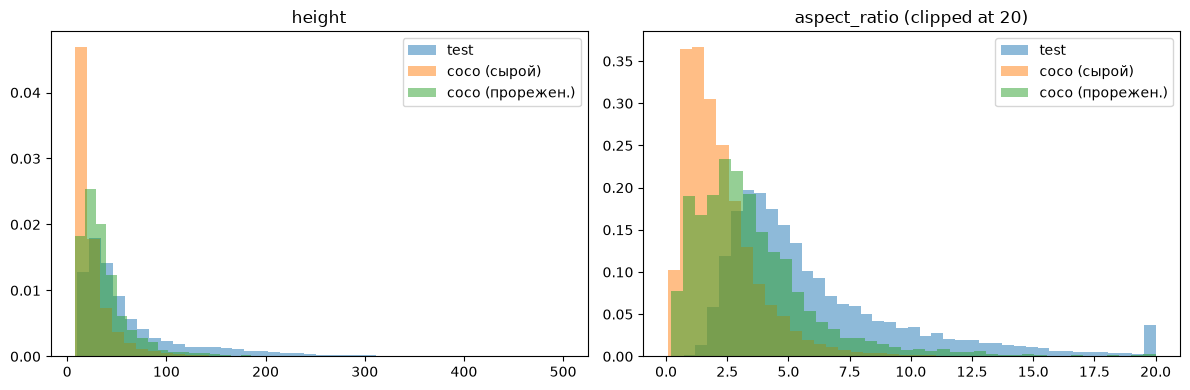

In [17]:
# Проверка: похоже ли распределение геометрии после прореживания на тест
def compute_aspect_ratio(df: pd.DataFrame) -> pd.Series:
    return (df["width"] / df["height"].clip(lower=1)).clip(lower=0.05, upper=60)


if len(coco_df_filtered) and "test_geometry" in dir():
    test_df_plot = pd.DataFrame(test_geometry)
    test_df_plot["aspect_ratio"] = compute_aspect_ratio(test_df_plot)
    coco_df_filtered["aspect_ratio"] = compute_aspect_ratio(coco_df_filtered)
    coco_df_raw_ar = compute_aspect_ratio(coco_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(test_df_plot["height"], bins=40, alpha=0.5, density=True, label="test")
    axes[0].hist(
        coco_df["height"].clip(upper=500),
        bins=40,
        alpha=0.5,
        density=True,
        label="coco (сырой)",
    )
    axes[0].hist(
        coco_df_filtered["height"],
        bins=40,
        alpha=0.5,
        density=True,
        label="coco (прорежен.)",
    )
    axes[0].set_title("height")
    axes[0].legend()

    axes[1].hist(
        test_df_plot["aspect_ratio"].clip(upper=20),
        bins=40,
        alpha=0.5,
        density=True,
        label="test",
    )
    axes[1].hist(
        coco_df_raw_ar.clip(upper=20),
        bins=40,
        alpha=0.5,
        density=True,
        label="coco (сырой)",
    )
    axes[1].hist(
        coco_df_filtered["aspect_ratio"].clip(upper=20),
        bins=40,
        alpha=0.5,
        density=True,
        label="coco (прорежен.)",
    )
    axes[1].set_title("aspect_ratio (clipped at 20)")
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(OUTPUTS_DIR / "figures_coco_geometry_match.png", dpi=120)
    plt.show()

In [18]:
def show_random_crops(df: pd.DataFrame, n: int = 24, seed: int = SEED):
    sample = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)

    ncols = 6
    nrows = int(np.ceil(len(sample) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows))
    axes = np.asarray(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = cv2.imread(row["crop_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        ax.set_title(
            f'{row["width"]}×{row["height"]}\n'
            f'ratio={row["width"] / row["height"]:.2f}',
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[len(sample) :]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


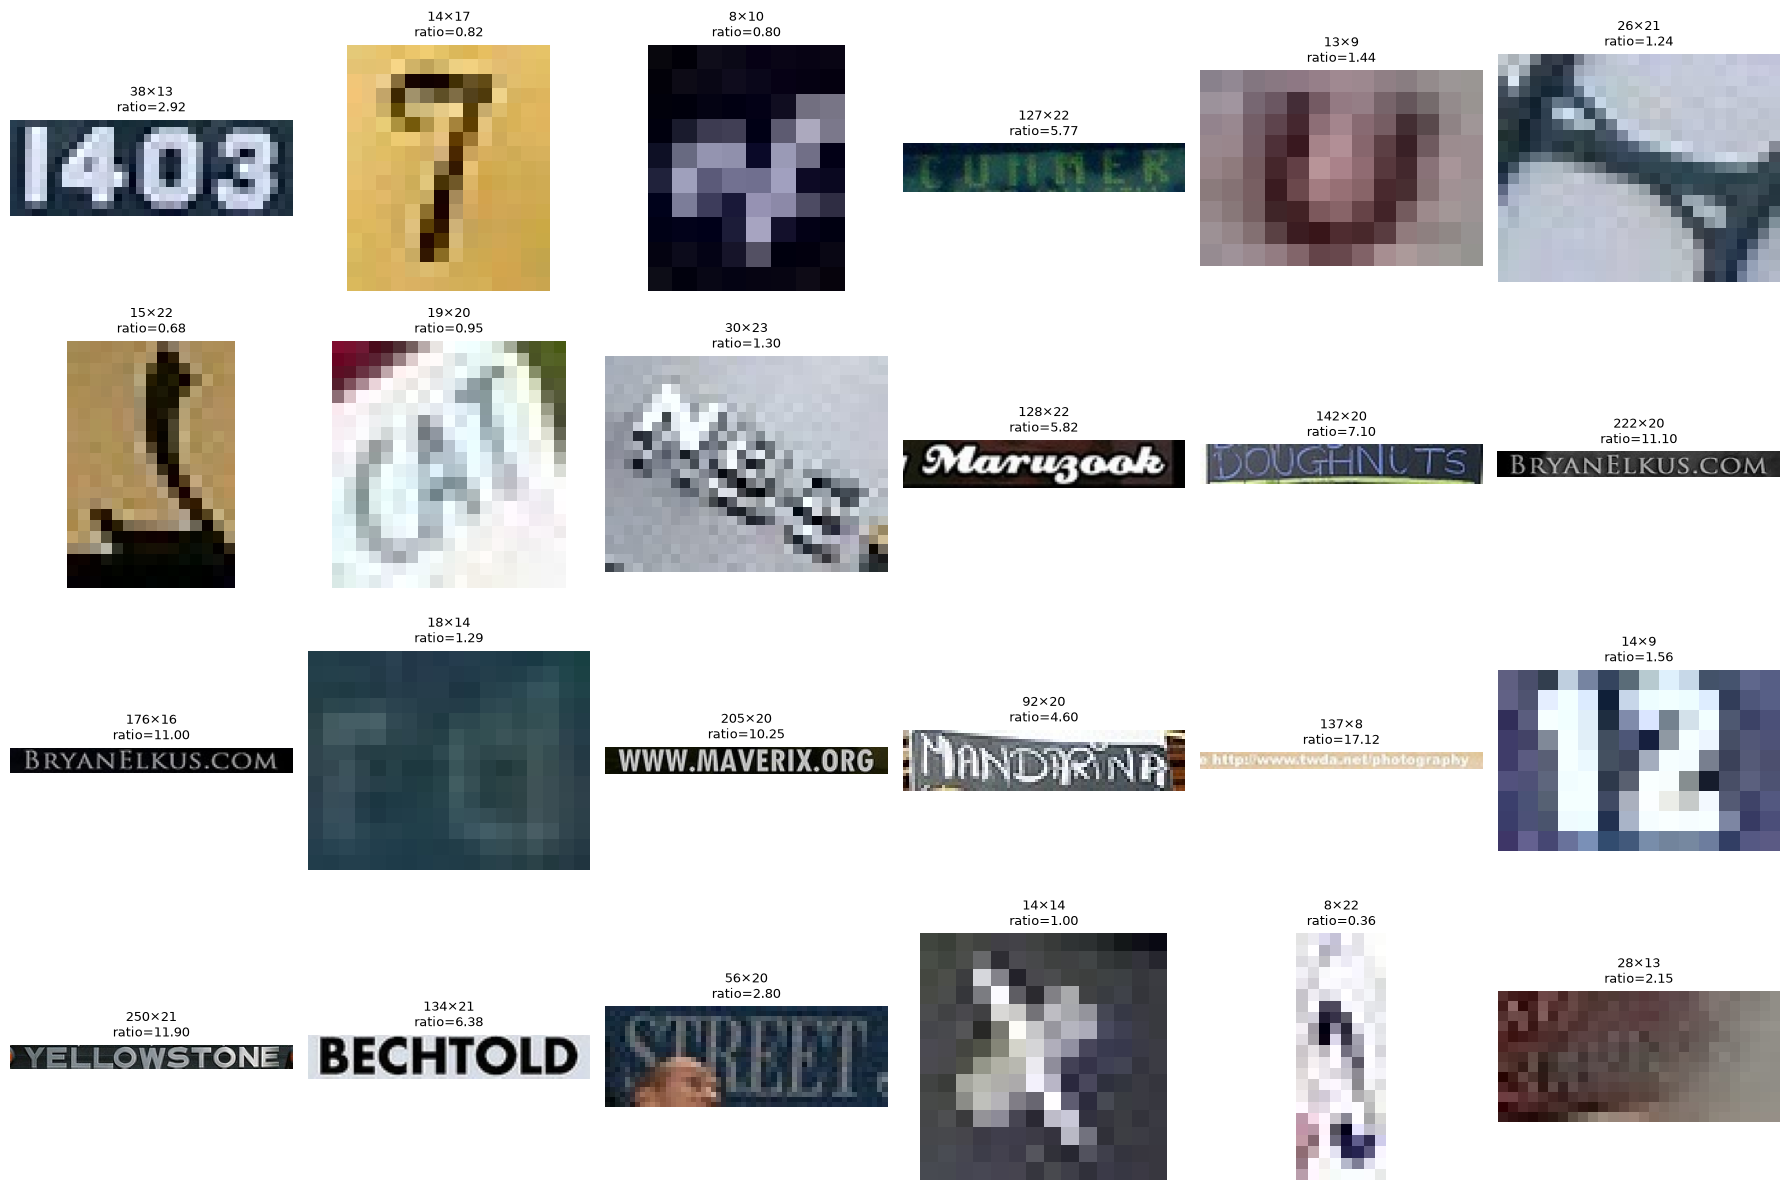

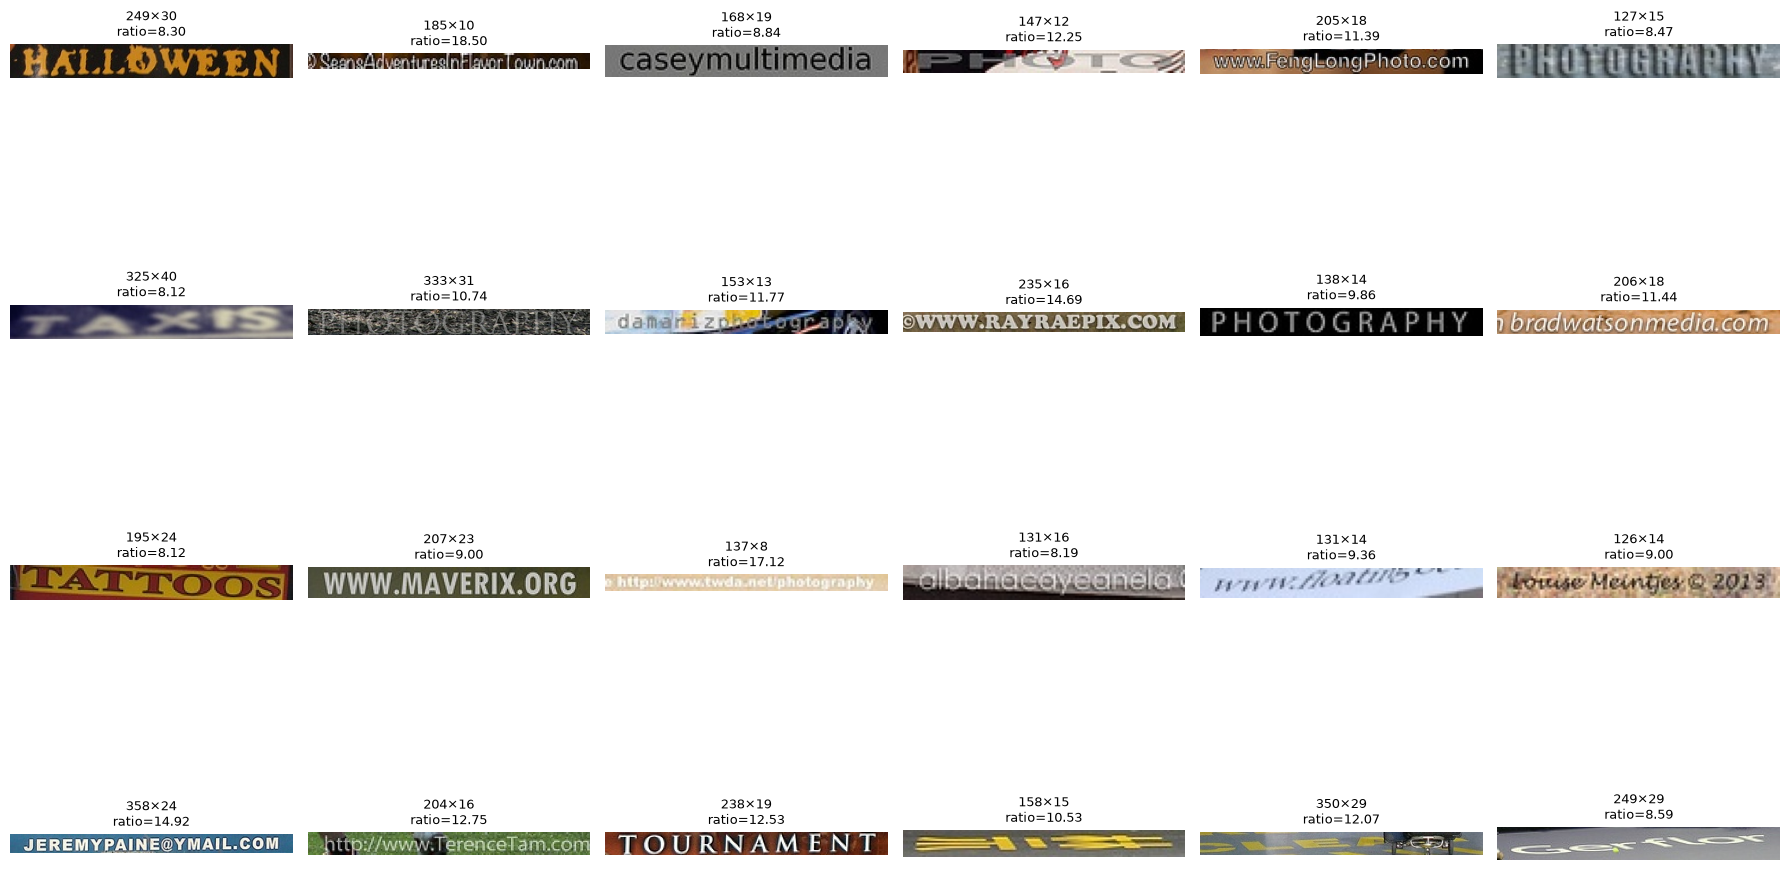

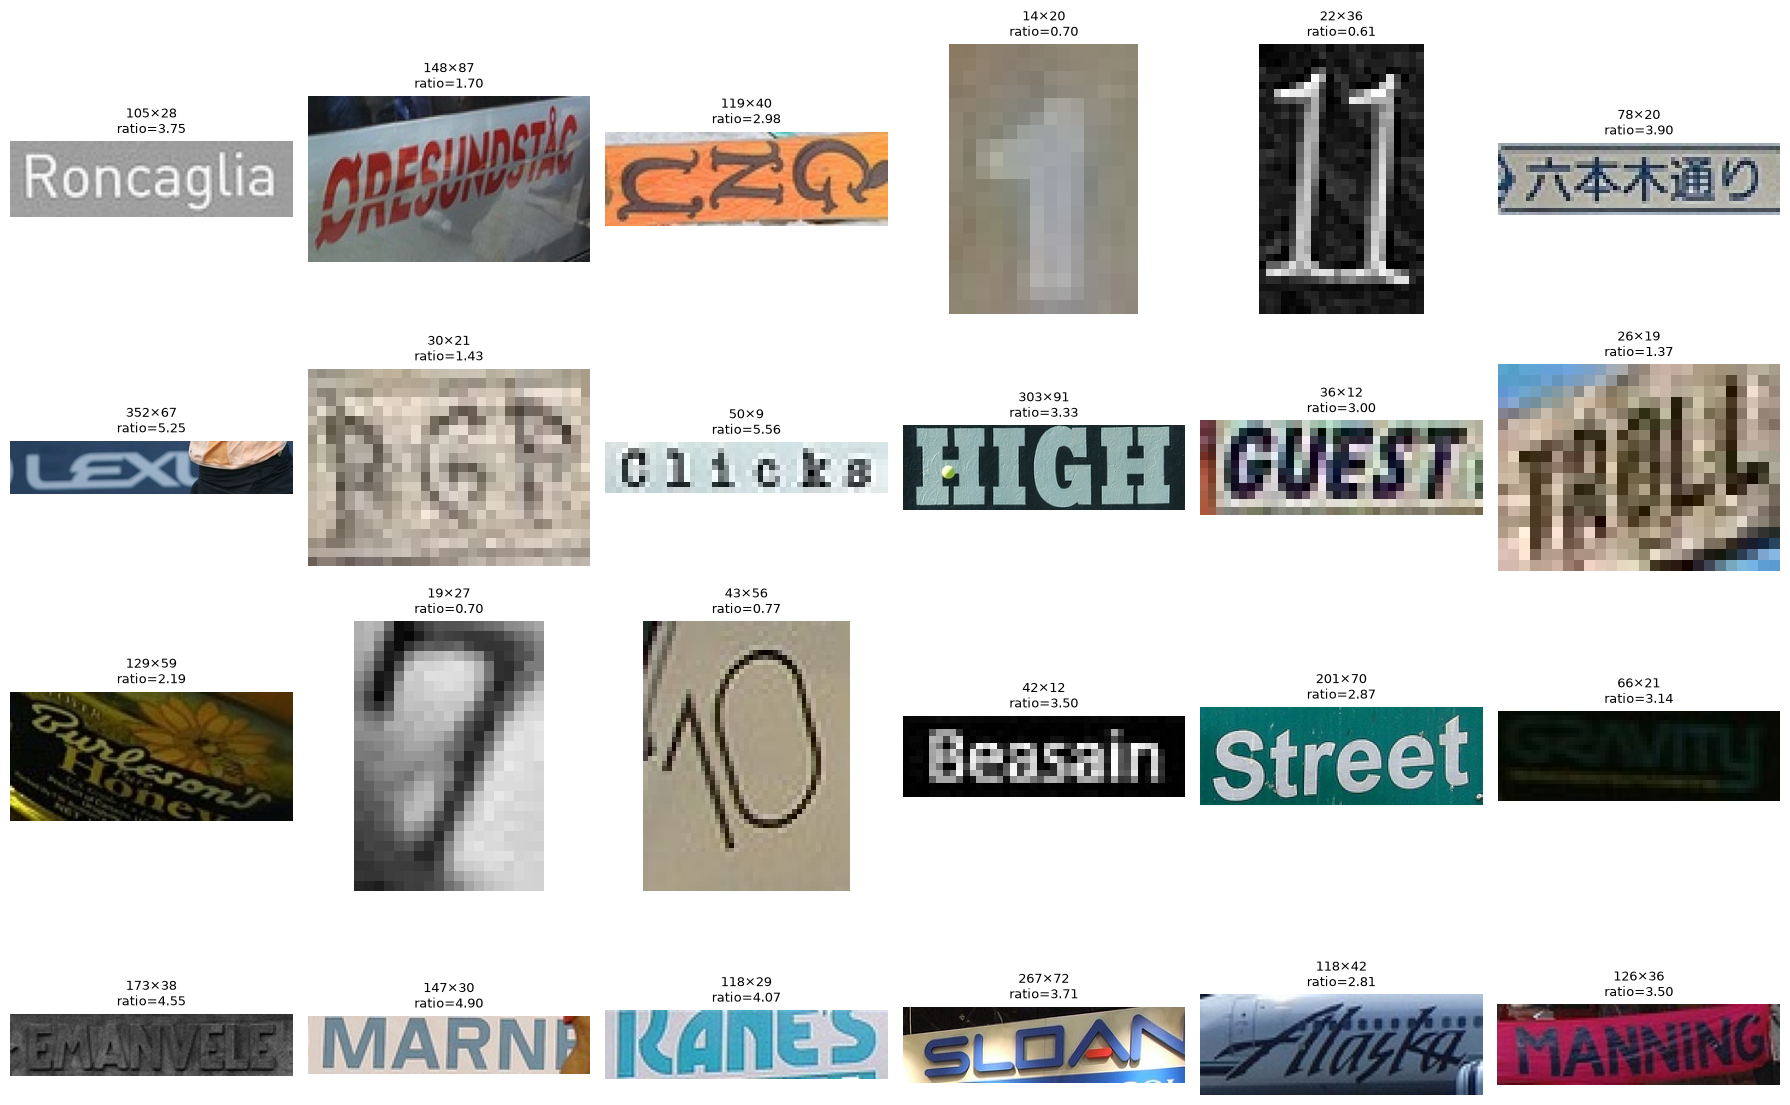

In [74]:
show_random_crops(coco_df_filtered.query("height < 24"), n=24, seed=42)
show_random_crops(coco_df_filtered.query("width / height > 8"), n=24, seed=43)
show_random_crops(coco_df_filtered.query("width / height <= 8"), n=24, seed=44)

### 2.3. Синтетические русско-английские текстовые кропы

Синтетическая часть выборки предназначена не для замены реальных изображений,
а для расширения визуального и языкового покрытия. Генератор формирует типичные
для объявлений текстовые конструкции:

- названия товаров и характеристики;
- цены и валютные обозначения;
- номера телефонов;
- адреса;
- названия брендов и моделей;
- русско-английские смешанные строки;
- короткие буквенно-цифровые коды.

Для рендеринга используется набор открытых TTF-шрифтов с поддержкой кириллицы.
Размер canvas выбирается по эмпирическому распределению ширины и высоты test
кропов. Размер шрифта и длина строки подбираются так, чтобы текст преимущественно
помещался в заданную геометрию; небольшое контролируемое кадрирование допускается
только для ограниченной доли примеров.

In [111]:
RU_WORDS = [
    # --- товары / продажа ---
    "продам",
    "куплю",
    "продаю",
    "обменяю",
    "даром",
    "торг",
    "оптом",
    "розница",
    "товар",
    "продукт",
    "вещь",
    "штука",
    "комплект",
    "набор",
    "партия",
    "новый",
    "новая",
    "новое",
    "б/у",
    "бу",
    "оригинал",
    "копия",
    "реплика",
    "качество",
    "отличное",
    "хорошее",
    "идеальное",
    "дефект",
    "брак",
    # --- цена / скидки ---
    "цена",
    "цены",
    "стоимость",
    "дешево",
    "недорого",
    "дорого",
    "скидка",
    "акция",
    "распродажа",
    "торг",
    "уценка",
    "выгодно",
    "бонус",
    "подарок",
    "рублей",
    "руб",
    "тысяч",
    "копейки",
    # --- доставка / самовывоз ---
    "доставка",
    "самовывоз",
    "отправка",
    "курьер",
    "почта",
    "сдэк",
    "boxberry",
    "сегодня",
    "завтра",
    "срочно",
    "быстро",
    "оперативно",
    "в наличии",
    "наличие",
    "заказ",
    "предзаказ",
    "резерв",
    "бронь",
    # --- характеристики ---
    "размер",
    "размеры",
    "цвет",
    "цвета",
    "материал",
    "кожа",
    "замша",
    "вес",
    "объем",
    "длина",
    "ширина",
    "высота",
    "диагональ",
    "модель",
    "версия",
    "поколение",
    "год",
    "производство",
    # --- гарантия / сервис ---
    "гарантия",
    "сервис",
    "ремонт",
    "обслуживание",
    "настройка",
    "установка",
    "консультация",
    "помощь",
    "поддержка",
    "доставка",
    "монтаж",
    # --- недвижимость / авто ---
    "квартира",
    "дом",
    "дача",
    "гараж",
    "участок",
    "комната",
    "студия",
    "машина",
    "авто",
    "автомобиль",
    "пробег",
    "двигатель",
    "коробка",
    "кузов",
    "салон",
    "шины",
    "диски",
    # --- электроника / связь ---
    "телефон",
    "смартфон",
    "ноутбук",
    "планшет",
    "наушники",
    "колонка",
    "монитор",
    "клавиатура",
    "мышь",
    "камера",
    "объектив",
    "зарядка",
    "кабель",
    "адаптер",
    "чехол",
    "стекло",
    # --- адрес / контакты ---
    "адрес",
    "улица",
    "ул",
    "проспект",
    "переулок",
    "дом",
    "корпус",
    "квартира",
    "офис",
    "магазин",
    "склад",
    "пункт",
    "выдачи",
    "телефон",
    "звонок",
    "ватсап",
    "телеграм",
    "whatsapp",
    "telegram",
    # --- общие ---
    "услуги",
    "работа",
    "вакансия",
    "требуется",
    "ищу",
    "найму",
    "срочно",
    "сегодня",
    "недорого",
    "качественно",
    "быстро",
    "звоните",
    "пишите",
    "спрашивайте",
    "уточняйте",
    "смотрите",
]

EN_WORDS = [
    "sale",
    "new",
    "price",
    "delivery",
    "shop",
    "discount",
    "original",
    "model",
    "service",
    "phone",
    "address",
    "online",
    "best",
    "offer",
    "available",
    "limited",
    "quality",
    "special",
    "premium",
    "store",
]

BRANDS = [
    "Apple",
    "Samsung",
    "Xiaomi",
    "HONOR",
    "HUAWEI",
    "Nike",
    "Adidas",
    "Sony",
    "LG",
    "BMW",
    "Toyota",
    "KIA",
    "HP",
    "Lenovo",
]


def random_realistic_text(rng: random.Random) -> str:
    kind = rng.choices(
        population=[
            "ru_words",
            "en_words",
            "price",
            "phone",
            "mixed",
            "brand_model",
            "address",
            "short_code",
        ],
        weights=[40, 8, 16, 8, 14, 8, 4, 2],
        k=1,
    )[0]

    if kind == "ru_words":
        return " ".join(rng.choices(RU_WORDS, k=rng.randint(2, 8)))

    if kind == "en_words":
        return " ".join(rng.choices(EN_WORDS, k=rng.randint(2, 8)))

    if kind == "price":
        price = rng.choice(
            [
                f"{rng.randint(1, 99)}",
                f"{rng.randint(100, 9999):,}".replace(",", " ") ,
                f"{rng.randint(1, 999)}.99",
                f"от {rng.randint(500, 99999):,}".replace(",", " "),
            ]
        )
        if rng.random() < 0.3:
            return f"{price} {rng.choice(['за штуку', 'за комплект', 'за месяц', 'за услугу'])}"

        return price

    if kind == "phone":
        return (
            f"+7 ({rng.randint(900, 999)}) "
            f"{rng.randint(100, 999)}-"
            f"{rng.randint(10, 99)}-"
            f"{rng.randint(10, 99)}"
        )

    if kind == "mixed":
        parts = [rng.choice(BRANDS)]
        parts += rng.choices(RU_WORDS, k=rng.randint(1, 4))  
        parts.append(str(rng.randint(1, 9999)))
        if rng.random() < 0.5:
            parts = [p.capitalize() if i == 0 or rng.random() < 0.3 else p
                    for i, p in enumerate(parts)]
        return " ".join(parts)

    if kind == "brand_model":
        return (
            f"{rng.choice(BRANDS)} "
            f"{rng.choice(['Pro', 'Max', 'Lite', 'Plus', 'X', 'S'])} "
            f"{rng.randint(5, 99)}"
        )

    if kind == "address":
        street = rng.choice(["Ленина", "Мира", "Победы", "Советская",
                            "Гагарина", "Пушкина", "Кирова", "Садовая"])
        parts = [f"ул. {street}", str(rng.randint(1, 250))]
        if rng.random() < 0.5:
            parts.append(f"кв. {rng.randint(1, 300)}")
        if rng.random() < 0.3:
            parts.append(f"корп. {rng.randint(1, 10)}")
        return ", ".join(parts)

    return "".join(
        rng.choice("АБВГДЕЖЗИКЛМНОПРСТУФХЦЧШЭЮЯ0123456789")
        for _ in range(rng.randint(4, 30))
    )

In [117]:
def luminance(rgb: tuple[int, int, int]) -> float:
    r, g, b = rgb
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def sample_contrast_colors(
    rng: random.Random,
    min_luma_diff: float = 70.0,
    p_dark_text: float = 0.70, 
) -> tuple[tuple[int, int, int], tuple[int, int, int]]:
    want_dark_text = rng.random() < p_dark_text
    
    if want_dark_text:
        bg = tuple(rng.randint(160, 255) for _ in range(3))
    else:
        bg = tuple(rng.randint(0, 95) for _ in range(3))

    for _ in range(50):
        if want_dark_text:
            fg = tuple(rng.randint(0, 90) for _ in range(3))
        else:
            fg = tuple(rng.randint(165, 255) for _ in range(3))

        if abs(luminance(bg) - luminance(fg)) >= min_luma_diff:
            return bg, fg

    # 4) fallback — как и раньше, но уже согласован с выбранной стороной
    fallback_fg = (0, 0, 0) if want_dark_text else (255, 255, 255)
    return bg, fallback_fg


def build_synthetic_upright_dataset(
    n_crops: int,
    font_paths: list[str],
    geometry_templates: list[dict],
    out_dir: Path,
    seed: int = SEED,
) -> pd.DataFrame:
    if not font_paths:
        raise ValueError(
            "Не найдено подходящих шрифтов. "
            "Добавьте TTF с поддержкой кириллицы в data/external/fonts/."
        )

    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)

    out_dir.mkdir(parents=True, exist_ok=True)
    records = []

    for i in range(n_crops):
        img_np, text, font_name = render_synthetic_upright_crop(
            rng=rng,
            np_rng=np_rng,
            font_paths=font_paths,
            geometry_templates=geometry_templates,
        )

        crop_id = f"synthru_{i:07d}"
        crop_path = out_dir / f"{crop_id}.jpg"

        saved = cv2.imwrite(
            str(crop_path),
            cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR),
            [int(cv2.IMWRITE_JPEG_QUALITY), 95],
        )

        if not saved:
            raise RuntimeError(f"Не удалось сохранить {crop_path}")

        records.append(
            {
                "crop_id": crop_id,
                "source": "synthetic_ru",
                "source_image_id": crop_id,
                "image_path": str(crop_path),
                "crop_path": str(crop_path),
                "width": int(img_np.shape[1]),
                "height": int(img_np.shape[0]),
                "aspect_ratio": float(img_np.shape[1] / max(img_np.shape[0], 1)),
                "text": text,
                "font_name": font_name,
                "language": "ru_en_mixed",
                "is_synthetic": True,
                "canonical_orientation": 0,
            }
        )

    result = pd.DataFrame(records)
    print(f"Синтетика: сгенерировано {len(result)} upright-кропов.")
    return result

def fit_text_to_canvas(
    rng: random.Random,
    font_path: str,
    text: str,
    canvas_w: int,
    canvas_h: int,
    max_attempts: int = 10,
):
    """
    Подбирает размер шрифта, чтобы текст преимущественно помещался в canvas.
    Возвращает font, bbox, text, margin_x, margin_y.
    """
    max_font_size = max(10, min(96, int(canvas_h * rng.uniform(0.55, 0.88))))
    min_font_size = max(8, int(canvas_h * 0.25))
    min_font_size = min(min_font_size, max_font_size)

    tmp_img = Image.new("RGB", (8, 8), "white")
    tmp_draw = ImageDraw.Draw(tmp_img)

    current_text = text

    for _ in range(max_attempts):
        font_size = rng.randint(min_font_size, max_font_size)
        font = ImageFont.truetype(font_path, font_size)

        bbox = tmp_draw.textbbox((0, 0), current_text, font=font)
        text_w = max(1, bbox[2] - bbox[0])
        text_h = max(1, bbox[3] - bbox[1])

        margin_x = max(2, int(canvas_w * rng.uniform(0.02, 0.08)))
        margin_y = max(2, int(canvas_h * rng.uniform(0.05, 0.18)))

        fits_w = text_w + 2 * margin_x <= canvas_w
        fits_h = text_h + 2 * margin_y <= canvas_h

        if fits_w and fits_h:
            return font, bbox, current_text, margin_x, margin_y

        # Если строка длинная, сначала сокращаем число слов.
        if " " in current_text and rng.random() < 0.75:
            parts = current_text.split()
            current_text = " ".join(parts[:-1])
            if not current_text:
                current_text = rng.choice(RU_WORDS)
        else:
            # Если это код/телефон/короткая строка — уменьшаем шрифт.
            max_font_size = max(min_font_size, int(max_font_size * 0.82))

    # Последняя попытка с минимальным шрифтом.
    font = ImageFont.truetype(font_path, min_font_size)
    bbox = tmp_draw.textbbox((0, 0), current_text, font=font)

    return font, bbox, current_text, 2, 2

def render_synthetic_upright_crop(
    rng: random.Random,
    np_rng: np.random.Generator,
    font_paths: list[str],
    geometry_templates: list[dict],
    min_canvas_side: int = 20,
    p_tight_crop: float = 0.12,
):
    """
    Генерирует upright synthetic crop с геометрией, близкой к test distribution.
    """
    target = rng.choice(geometry_templates)

    canvas_w = max(min_canvas_side, int(target["width"]))
    canvas_h = max(min_canvas_side, int(target["height"]))
    
    text = random_realistic_text(rng)
    font_path = rng.choice(font_paths)

    font, bbox, text, margin_x, margin_y = fit_text_to_canvas(
        rng=rng,
        font_path=font_path,
        text=text,
        canvas_w=canvas_w,
        canvas_h=canvas_h,
    )

    text_w = max(1, bbox[2] - bbox[0])
    text_h = max(1, bbox[3] - bbox[1])

    bg_color, text_color = sample_contrast_colors(rng)

    img = Image.new("RGB", (canvas_w, canvas_h), bg_color)
    draw = ImageDraw.Draw(img)

    # Большинство примеров: текст гарантированно внутри canvas.
    if rng.random() >= p_tight_crop:
        available_x = max(0, canvas_w - text_w - 2 * margin_x)
        available_y = max(0, canvas_h - text_h - 2 * margin_y)

        x = margin_x + rng.randint(0, available_x)
        y = margin_y + rng.randint(0, available_y)

    # Небольшая доля примеров: небольшой controlled crop по краям.
    else:
        x_min = -max(1, int(0.08 * text_w))
        x_max = max(x_min, canvas_w - text_w + max(1, int(0.08 * text_w)))

        y_min = -max(1, int(0.05 * text_h))
        y_max = max(y_min, canvas_h - text_h + max(1, int(0.05 * text_h)))

        x = rng.randint(x_min, x_max)
        y = rng.randint(y_min, y_max)

    draw.text(
        (x - bbox[0], y - bbox[1]),
        text,
        font=font,
        fill=text_color,
        stroke_width=rng.choices([0, 1], weights=[0.92, 0.08], k=1)[0],
        stroke_fill=text_color,
    )

    img_np = np.asarray(img).copy()

    # Держим генераторные артефакты умеренными:
    if rng.random() < 0.12:
        kernel = rng.choice([3, 5])
        img_np = cv2.GaussianBlur(img_np, (kernel, kernel), 0)

    if rng.random() < 0.12:
        sigma = rng.uniform(3.0, 12.0)
        noise = np_rng.normal(
            0.0,
            sigma,
            size=img_np.shape,
        ).astype(np.float32)
        img_np = np.clip(
            img_np.astype(np.float32) + noise,
            0,
            255,
        ).astype(np.uint8)

    if rng.random() < 0.18:
        jpeg_quality = rng.randint(45, 95)

        success, encoded = cv2.imencode(
            ".jpg",
            cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR),
            [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality],
        )

        if success:
            decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
            if decoded is not None:
                img_np = cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB)

    return img_np, text, Path(font_path).name

In [118]:
FONTS_DIR = EXTERNAL_DIR / "fonts"
FONT_PATHS = sorted(FONTS_DIR.rglob("*.ttf"))
N_SYNTHETIC = 15_000

synth_df = build_synthetic_upright_dataset(
    n_crops=N_SYNTHETIC,
    font_paths=FONT_PATHS,
    geometry_templates=test_geometry,
    out_dir=SYNTH_DIR,
    seed=SEED,
)

synth_df.to_csv(
    PROCESSED_DIR / "synthetic_ru_metadata.csv",
    index=False,
)

print(synth_df.shape)
display(synth_df.head())


Синтетика: сгенерировано 15000 upright-кропов.
(15000, 13)


,crop_id,source,source_image_id,image_path,crop_path,width,height,aspect_ratio,text,font_name,language,is_synthetic,canonical_orientation
0,synthru_0000000,synthetic_ru,synthru_0000000,/Users/vika/Projects/classifier_rotation/data/...,/Users/vika/Projects/classifier_rotation/data/...,66,28,2.357143,уценка,ofont.ru_Bookman Old Style Cyr.ttf,ru_en_mixed,True,0
1,synthru_0000001,synthetic_ru,synthru_0000001,/Users/vika/Projects/classifier_rotation/data/...,/Users/vika/Projects/classifier_rotation/data/...,1238,243,5.094650,1 239,ofont.ru_Bookman Old Style Cyr.ttf,ru_en_mixed,True,0
2,synthru_0000002,synthetic_ru,synthru_0000002,/Users/vika/Projects/classifier_rotation/data/...,/Users/vika/Projects/classifier_rotation/data/...,379,63,6.015873,8ПХГПВХЮТДО9ХО4Ю2КСИР87С,ofont.ru_Smooz.ttf,ru_en_mixed,True,0
3,synthru_0000003,synthetic_ru,synthru_0000003,/Users/vika/Projects/classifier_rotation/data/...,/Users/vika/Projects/classifier_rotation/data/...,160,26,6.153846,BMW Lite 67,ofont.ru_ArbatDi.ttf,ru_en_mixed,True,0
4,synthru_0000004,synthetic_ru,synthru_0000004,/Users/vika/Projects/classifier_rotation/data/...,/Users/vika/Projects/classifier_rotation/data/...,450,26,17.307692,premium limited offer,ofont.ru_Hirro Sans.ttf,ru_en_mixed,True,0


In [120]:
def geometry_summary(
    df: pd.DataFrame,
    name: str,
    width_col: str = "width",
    height_col: str = "height",
) -> dict:
    width = df[width_col].astype(float)
    height = df[height_col].astype(float)
    ratio = width / height.clip(lower=1)

    return {
        "dataset": name,
        "n": len(df),
        "width_median": width.median(),
        "width_p05": width.quantile(0.05),
        "width_p95": width.quantile(0.95),
        "height_median": height.median(),
        "height_p05": height.quantile(0.05),
        "height_p95": height.quantile(0.95),
        "ratio_median": ratio.median(),
        "ratio_p05": ratio.quantile(0.05),
        "ratio_p95": ratio.quantile(0.95),
        "share_tiny_side_lt16": ((width < 16) | (height < 16)).mean(),
        "share_ratio_gt8": (ratio > 8).mean(),
    }


test_audit_for_compare = audit_df.loc[
    audit_df["readable"],
    ["width", "height"],
].copy()

datasets_geometry_df = pd.DataFrame(
    [
        geometry_summary(test_audit_for_compare, "test"),
        geometry_summary(coco_df_filtered, "coco_filtered"),
        geometry_summary(synth_df, "synthetic_ru"),
    ]
)

display(datasets_geometry_df.round(3))

datasets_geometry_df.to_csv(
    OUTPUTS_DIR / "geometry_summary_test_coco_synth.csv",
    index=False,
)

,dataset,n,width_median,width_p05,width_p95,height_median,height_p05,height_p95,ratio_median,ratio_p05,ratio_p95,share_tiny_side_lt16,share_ratio_gt8
0,test,20000,238.0,61.0,1047.0,42.0,16.0,195.0,4.895,2.320,14.448,0.048,0.221
1,coco_filtered,5006,122.0,16.0,303.0,30.0,10.0,91.0,3.000,0.765,8.407,0.155,0.057
2,synthetic_ru,15000,236.0,61.0,1055.1,43.0,20.0,195.0,4.741,2.184,13.950,0.000,0.206


Синтетическая выборка хорошо воспроизводит основные характеристики тестовых
кропов: медианные ширина, высота и aspect ratio близки к тестовому распределению.
В частности, для test и synthetic наборов медианная ширина составляет 238 px
и 236 px соответственно, медианная высота — 42 px и 43 px, а медианный aspect
ratio — 4.90 и 4.74. Доля длинных строк с aspect ratio более 8 также близка:
22.1% в test и 20.6% в synthetic data.

Отфильтрованный COCO-Text остаётся более компактным по геометрии, но добавляет
реальные сцены и визуальные искажения. Поэтому реальная и синтетическая части
используются совместно.

In [121]:
COMMON_COLS = [
    "crop_id",
    "source",
    "source_image_id",
    "crop_path",
    "width",
    "height",
    "is_synthetic",
]

coco_for_pool = coco_df_filtered[COMMON_COLS].copy()
synth_for_pool = synth_df[COMMON_COLS].copy()

train_pool_df = pd.concat(
    [coco_for_pool, synth_for_pool],
    ignore_index=True,
)

train_pool_df["aspect_ratio"] = train_pool_df["width"] / train_pool_df["height"].clip(
    lower=1
)

train_pool_df = train_pool_df.sample(
    frac=1.0,
    random_state=SEED,
).reset_index(drop=True)

print("Размер объединённого пула:", train_pool_df.shape)
print("\nРаспределение источников:")
print(train_pool_df["source"].value_counts())

assert train_pool_df["crop_id"].is_unique
assert train_pool_df["crop_path"].notna().all()
assert (train_pool_df["width"] > 0).all()
assert (train_pool_df["height"] > 0).all()

train_pool_df.to_csv(
    PROCESSED_DIR / "train_pool_metadata.csv",
    index=False,
)

Размер объединённого пула: (20006, 8)

Распределение источников:
source
synthetic_ru    15000
coco_text        5006
Name: count, dtype: int64


### 2.6. Разделение на train / val_id / val_holdout

Разбиение реальных COCO-кропов выполняется по `source_image_id`, а не по
отдельным crop. Это предотвращает утечку: соседние текстовые регионы одного
исходного изображения имеют общий фон, освещение, компрессию и визуальный стиль.

Используются три части:

- `train` — обучение параметров модели;
- `val_id` — мониторинг обучения и ранняя диагностика;
- `val_holdout` — независимое сравнение финальных кандидатов.

Synthetic-кропы используются в train и частично в `val_id` для контроля
корректности генератора. Финальная оценка выбора модели выполняется прежде всего
на real-image holdout, а не на synthetic validation.

In [122]:

def split_real_by_source_image(
    df: pd.DataFrame,
    seed: int = SEED,
    train_frac: float = 0.70,
    val_id_frac: float = 0.15,
) -> pd.DataFrame:
    """
    Делит реальные данные по source_image_id.
    Все crop'ы одного исходного изображения находятся строго в одном split.
    """
    if not np.isclose(train_frac + 2 * val_id_frac, 1.0):
        raise ValueError("Ожидается train_frac + 2 * val_id_frac == 1.0")

    result = df.copy()

    source_ids = np.array(sorted(result["source_image_id"].dropna().unique()))

    train_ids, temp_ids = train_test_split(
        source_ids,
        train_size=train_frac,
        random_state=seed,
        shuffle=True,
    )

    val_id_relative = val_id_frac / (1.0 - train_frac)

    val_id_ids, val_holdout_ids = train_test_split(
        temp_ids,
        train_size=val_id_relative,
        random_state=seed,
        shuffle=True,
    )

    split_map = {
        **{source_id: "train" for source_id in train_ids},
        **{source_id: "val_id" for source_id in val_id_ids},
        **{source_id: "val_holdout" for source_id in val_holdout_ids},
    }

    result["split"] = result["source_image_id"].map(split_map)

    if result["split"].isna().any():
        raise RuntimeError("Некоторые source_image_id не получили split.")

    split_sets = {
        split: set(result.loc[result["split"] == split, "source_image_id"])
        for split in ["train", "val_id", "val_holdout"]
    }

    assert not (split_sets["train"] & split_sets["val_id"])
    assert not (split_sets["train"] & split_sets["val_holdout"])
    assert not (split_sets["val_id"] & split_sets["val_holdout"])

    return result

In [123]:
def split_synthetic(
    df: pd.DataFrame,
    seed: int = SEED,
    train_frac: float = 0.90,
) -> pd.DataFrame:
    """
    Синтетические изображения независимы: у каждого свой source_image_id.
    Оставляем 10% для диагностики генератора, но не используем как главный
    критерий выбора финальной модели.
    """
    result = df.copy()

    rng = np.random.default_rng(seed)
    indices = np.arange(len(result))
    rng.shuffle(indices)

    n_train = int(round(train_frac * len(result)))
    train_indices = set(indices[:n_train])

    result["split"] = [
        "train" if idx in train_indices else "val_id" for idx in range(len(result))
    ]

    return result

In [124]:
coco_split_df = split_real_by_source_image(
    coco_for_pool,
    seed=SEED,
    train_frac=0.70,
    val_id_frac=0.15,
)

synth_split_df = split_synthetic(
    synth_for_pool,
    seed=SEED,
    train_frac=0.90,
)

data_df = pd.concat(
    [coco_split_df, synth_split_df],
    ignore_index=True,
)

data_df["aspect_ratio"] = data_df["width"] / data_df["height"].clip(lower=1)

data_df = data_df.sample(
    frac=1.0,
    random_state=SEED,
).reset_index(drop=True)

assert data_df["crop_id"].is_unique
assert data_df["split"].notna().all()

print(
    data_df.groupby(["source", "split"])
    .agg(
        n_crops=("crop_id", "count"),
        n_source_images=("source_image_id", "nunique"),
        width_median=("width", "median"),
        height_median=("height", "median"),
        ratio_median=("aspect_ratio", "median"),
    )
    .round(2)
)

data_df.to_csv(
    SPLITS_DIR / "orientation_data_splits.csv",
    index=False,
)

                          n_crops  n_source_images  width_median  \
source       split                                                 
coco_text    train           3509             2567         122.0   
             val_holdout      750              551         119.0   
             val_id           747              550         122.0   
synthetic_ru train          13500            13500         237.0   
             val_id          1500             1500         230.0   

                          height_median  ratio_median  
source       split                                     
coco_text    train                 30.0          3.01  
             val_holdout           30.0          3.08  
             val_id                31.0          2.90  
synthetic_ru train                 43.0          4.74  
             val_id                42.0          4.69  


## 3. Препроцессинг входа и PyTorch `Dataset`

Для батчевого обучения нужен фиксированный размер тензора, поэтому все изображения
приводятся к `64 × 256` с сохранением aspect ratio: масштабирование по высоте до
64 px, при необходимости сжатие по ширине до 256 px, оставшаяся область
дополняется padding. Такое представление соответствует преимущественно
горизонтальной геометрии тестовых кропов (раздел 1.1) и не искажает пропорции
текста, в отличие от жёсткого resize до квадрата.


In [125]:
INPUT_H = 64
INPUT_W = 256


def resize_keep_aspect_and_pad(
    image: np.ndarray,
    out_h: int = INPUT_H,
    out_w: int = INPUT_W,
    pad_value: int = 127,
) -> np.ndarray:
    """
    Resize с сохранением aspect ratio и padding справа/снизу.
    Для очень широкого изображения ширина ограничивается out_w.
    """
    if image is None:
        raise ValueError("Получено пустое изображение.")

    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.ndim == 3 and image.shape[2] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

    h, w = image.shape[:2]

    scale = out_h / max(h, 1)
    resized_w = max(1, int(round(w * scale)))

    if resized_w > out_w:
        resized_w = out_w

    resized = cv2.resize(
        image,
        (resized_w, out_h),
        interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC,
    )

    padded = np.full(
        (out_h, out_w, 3),
        fill_value=pad_value,
        dtype=np.uint8,
    )

    padded[:, :resized_w] = resized

    return padded

### 3.1. `TextOrientationDataset`: генерация метки 180° "на лету"

Поворот на $180^\circ$ применяется **до** resize и padding, а не после. Порядок
операций здесь принципиален: если бы поворот выполнялся после padding, у модели
появился бы паразитный сигнал — по расположению padding-области можно было бы
отличать классы 0° и 180°, вообще не глядя на сам текст, и offline-оценка
качества оказалась бы завышенной и нерелевантной test-домену.

Для реальных (`coco_text`) crop'ов метка не хранится в метаданных: `Dataset`
сам решает на каждой эпохе, поворачивать конкретный пример или нет (см.
`_get_label`) — это эквивалент online-аугментации класса и не требует
физического дублирования файлов на диске. Для synthetic-кропов, где ориентация
уже "запечена" в сгенерированный файл на этапе рендеринга, используется явная
колонка `label_180`.


In [151]:
import torch
from torch.utils.data import Dataset


class TextOrientationDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        transform=None,
        input_h: int = INPUT_H,
        input_w: int = INPUT_W,
        train_mode: bool = False,
        seed: int = SEED,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.input_h = input_h
        self.input_w = input_w
        self.train_mode = train_mode
        self.seed = seed

        if "crop_path" not in self.df.columns:
            raise ValueError("В dataframe отсутствует колонка crop_path.")

    def __len__(self):
        return len(self.df)

    def set_epoch(self, epoch: int):
        self.epoch = int(epoch)

    def _get_label(self, idx: int) -> int:
        if "label_180" in self.df.columns:
            return int(self.df.iloc[idx]["label_180"])

        if self.train_mode:
            rng = random.Random(
                self.seed + 1_000_003 * self.epoch + idx
            )
            return int(rng.random() < 0.5)

        return int(idx % 2 == 1)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        image = cv2.imread(str(row["crop_path"]), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Не удалось прочитать: {row['crop_path']}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = self._get_label(idx)

        if label == 1:
            image = cv2.rotate(image, cv2.ROTATE_180)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        image = resize_keep_aspect_and_pad(
            image,
            out_h=self.input_h,
            out_w=self.input_w,
        )

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        return {
            "image": torch.from_numpy(image),
            "label": torch.tensor(label, dtype=torch.float32),
            "crop_id": row["crop_id"],
            "source": row["source"],
        }

## 4. Оценка моделей: PaddleOCR baseline и собственные CNN


### 4.1. PaddleOCR baseline: holdout-выборка

Оценка проводится на `val_holdout` — части реальных COCO-Text изображений,
не участвовавшей ни в подборе геометрии (2.2), ни в обучении собственных CNN.
Для честного сравнения ниже используется один и тот же holdout и один и тот же
протокол построения пар (0°/180°) — как для PaddleOCR, так и для CNN-моделей.


In [152]:
VAL_SPLIT = "val_holdout"

paddle_val_df = (
    data_df[(data_df["split"] == VAL_SPLIT) & (data_df["source"] == "coco_text")]
    .copy()
    .sort_values("crop_id")
    .reset_index(drop=True)
)

print("PaddleOCR validation images:", len(paddle_val_df))
display(paddle_val_df.head())

PaddleOCR validation images: 750


,crop_id,source,source_image_id,crop_path,width,height,is_synthetic,split,aspect_ratio
0,coco_10062_0000,coco_text,10062.jpg,/Users/vika/Projects/classifier_rotation/data/...,42,12,False,val_holdout,3.500000
1,coco_1007_0000,coco_text,1007.jpg,/Users/vika/Projects/classifier_rotation/data/...,120,49,False,val_holdout,2.448980
2,coco_1007_0001,coco_text,1007.jpg,/Users/vika/Projects/classifier_rotation/data/...,155,57,False,val_holdout,2.719298
3,coco_10116_0000,coco_text,10116.jpg,/Users/vika/Projects/classifier_rotation/data/...,145,42,False,val_holdout,3.452381
4,coco_10142_0000,coco_text,10142.jpg,/Users/vika/Projects/classifier_rotation/data/...,38,18,False,val_holdout,2.111111


In [130]:
def make_orientation_eval_df(
    df: pd.DataFrame,
    path_col: str = "crop_path",
) -> pd.DataFrame:
    base = df.copy()

    normal = base.copy()
    normal["label_180"] = 0

    rotated = base.copy()
    rotated["label_180"] = 1

    eval_df = pd.concat([normal, rotated], ignore_index=True)

    eval_df["eval_id"] = (
        eval_df["crop_id"].astype(str) + "_rot" + eval_df["label_180"].astype(str)
    )

    return eval_df.sample(
        frac=1.0,
        random_state=SEED,
    ).reset_index(drop=True)


paddle_eval_df = make_orientation_eval_df(paddle_val_df)

print("Paddle eval size:", len(paddle_eval_df))
print(paddle_eval_df["label_180"].value_counts())

Paddle eval size: 1500
label_180
1    750
0    750
Name: count, dtype: int64


In [131]:
from paddlex import create_model
paddle_model = create_model(model_name="PP-LCNet_x0_25_textline_ori")
def extract_paddle_p180(result) -> float:
    """
    Преобразует результат PP-LCNet text-line orientation classifier
    в вероятность p_180.
    """
    if hasattr(result, "json"):
        result = result.json

    if isinstance(result, dict) and "res" in result:
        result = result["res"]

    class_ids = np.asarray(result["class_ids"]).reshape(-1)
    scores = np.asarray(result["scores"]).reshape(-1)
    label_names = result.get("label_names", [])

    class_id = int(class_ids[0])
    score = float(scores[0])

    if class_id == 1:
        return score

    if class_id == 0:
        return 1.0 - score

    raise ValueError(f"Неожиданный class_id={class_id}; " f"label_names={label_names}")

/Users/vika/Projects/classifier_rotation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x0_25_textline_ori), the model files will be automatically downloaded and saved in `/Users/vika/.paddlex/official_models/PP-LCNet_x0_25_textline_ori`.
Fetching 6 files: 100%|██████████| 6/6 [00:01<00:00,  3.11it/s]
/Users/vika/Projects/classifier_rotation/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  w

In [ ]:
example_path = paddle_val_df.iloc[0]["crop_path"]

example_output = list(
    paddle_model.predict(
        input=example_path,
        batch_size=1,
    )
)[0]

print(example_output.json)

In [133]:
import time
import tempfile


def paddle_predict_p180_for_array(
    model,
    image_rgb: np.ndarray,
    tmp_dir: Path,
    file_stem: str,
) -> float:
    """
    Запускает PaddleX/PaddleOCR orientation model на RGB-массиве.
    Временный файл удаляется после inference.
    """
    tmp_path = tmp_dir / f"{file_stem}.jpg"

    ok = cv2.imwrite(
        str(tmp_path),
        cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR),
        [int(cv2.IMWRITE_JPEG_QUALITY), 100],
    )

    if not ok:
        raise RuntimeError(f"Не удалось записать временный файл: {tmp_path}")

    try:
        result = list(
            model.predict(
                input=str(tmp_path),
                batch_size=1,
            )
        )[0]

        p_180 = extract_paddle_p180(result)

    finally:
        if tmp_path.exists():
            tmp_path.unlink()

    return float(np.clip(p_180, 0.0, 1.0))

In [134]:
from tqdm.auto import tqdm


def evaluate_paddle_orientation(
    model,
    eval_df: pd.DataFrame,
) -> pd.DataFrame:
    records = []

    with tempfile.TemporaryDirectory() as tmp:
        tmp_dir = Path(tmp)

        start_time = time.perf_counter()

        for row_idx, row in tqdm(
            eval_df.iterrows(),
            total=len(eval_df),
            desc="PaddleOCR evaluation",
        ):
            image_bgr = cv2.imread(
                str(row["crop_path"]),
                cv2.IMREAD_COLOR,
            )

            if image_bgr is None:
                raise FileNotFoundError(row["crop_path"])

            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

            if int(row["label_180"]) == 1:
                image_rgb = cv2.rotate(
                    image_rgb,
                    cv2.ROTATE_180,
                )

            p_180 = paddle_predict_p180_for_array(
                model=model,
                image_rgb=image_rgb,
                tmp_dir=tmp_dir,
                file_stem=f"sample_{row_idx:08d}",
            )

            records.append(
                {
                    "eval_id": row["eval_id"],
                    "crop_id": row["crop_id"],
                    "source": row["source"],
                    "label_180": int(row["label_180"]),
                    "p_180": p_180,
                }
            )

        elapsed_sec = time.perf_counter() - start_time

    pred_df = pd.DataFrame(records)

    print(f"Total time: {elapsed_sec:.2f} sec")
    print(f"Images/sec: {len(pred_df) / elapsed_sec:.2f}")
    print(f"Milliseconds/image: {1000 * elapsed_sec / len(pred_df):.2f}")

    return pred_df

In [135]:
paddle_pred_df = evaluate_paddle_orientation(
    model=paddle_model,
    eval_df=paddle_eval_df,
)

paddle_pred_df.to_csv(
    OUTPUTS_DIR / "paddle_val_predictions.csv",
    index=False,
)

display(paddle_pred_df.head())

PaddleOCR evaluation: 100%|██████████| 1500/1500 [00:06<00:00, 241.34it/s]

Total time: 6.32 sec
Images/sec: 237.41
Milliseconds/image: 4.21


,eval_id,crop_id,source,label_180,p_180
0,coco_1949_0000_rot1,coco_1949_0000,coco_text,1,0.99999
1,coco_7007_0002_rot1,coco_7007_0002,coco_text,1,0.98984
2,coco_2930_0000_rot0,coco_2930_0000,coco_text,0,0.00042
3,coco_2711_0000_rot0,coco_2711_0000,coco_text,0,0.17948
4,coco_3504_0007_rot0,coco_3504_0007,coco_text,0,0.03037


In [138]:
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)


def compute_orientation_metrics(
    pred_df: pd.DataFrame,
    y_col: str = "label_180",
    p_col: str = "p_180",
) -> dict:
    y_true = pred_df[y_col].to_numpy(dtype=int)
    p_180 = np.clip(
        pred_df[p_col].to_numpy(dtype=float),
        1e-7,
        1.0 - 1e-7,
    )

    y_pred = (p_180 >= 0.5).astype(int)

    brier = brier_score_loss(y_true, p_180)

    return {
        "n": len(pred_df),
        "brier": brier,
        "1_minus_brier": 1.0 - brier,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_180),
        "log_loss": log_loss(y_true, p_180, labels=[0, 1]),
        "mean_p_180": float(p_180.mean()),
        "mean_p_180_label0": float(p_180[y_true == 0].mean()),
        "mean_p_180_label1": float(p_180[y_true == 1].mean()),
    }


paddle_metrics = compute_orientation_metrics(paddle_pred_df)

pd.DataFrame([paddle_metrics]).round(6)

,n,brier,1_minus_brier,accuracy,roc_auc,log_loss,mean_p_180,mean_p_180_label0,mean_p_180_label1
0,1500,0.156435,0.843565,0.793333,0.911269,0.587406,0.36874,0.085485,0.651994


In [137]:
paddle_pred_df.groupby("label_180")["p_180"].describe()

,count,mean,std,min,25%,50%,75%,max
label_180,,,,,,,,
0,750.0,0.085485,0.195468,0.00000,0.000283,0.00317,0.051065,0.99946
1,750.0,0.651994,0.382744,0.00007,0.256712,0.85368,0.992950,1.00000


### 4.2. Собственные компактные CNN: данные, аугментации, обучение

Сравниваются две компактные архитектуры с ImageNet-инициализацией —
`MobileNetV3-Small` и `ShuffleNetV2 x0.5`. Обе — стандартный выбор для
CPU/on-device инференса в проде и хорошо соответствуют требованию задания к
скорости и компактности модели, применяемой к каждому боксу каждого
изображения.


In [160]:
from torch.utils.data import DataLoader
from torchvision import transforms

DEVICE = (
    "mps"
    if torch.backends.mps.is_available()
    else ("cuda" if torch.cuda.is_available() else "cpu")
)
print("Device:", DEVICE)

BATCH_SIZE = 128 if DEVICE != "cpu" else 16
NUM_WORKERS = 0 

train_df = data_df.query("split == 'train'").reset_index(drop=True)
val_id_df = data_df.query("split == 'val_id'").reset_index(drop=True)
val_holdout_df = data_df.query("split == 'val_holdout'").reset_index(drop=True)

print(train_df.groupby("source").size())
print(val_id_df.groupby("source").size())
print(val_holdout_df.groupby("source").size())

Device: mps
source
coco_text        3509
synthetic_ru    13500
dtype: int64
source
coco_text        747
synthetic_ru    1500
dtype: int64
source
coco_text    750
dtype: int64


In [ ]:
cnn_holdout_eval_df = make_orientation_eval_df(
    val_holdout_df[val_holdout_df["source"] == "coco_text"].copy()
)

cnn_holdout_eval_dataset = TextOrientationDataset(
    cnn_holdout_eval_df,
    transform=None,
    train_mode=False,
    seed=SEED,
)

cnn_holdout_eval_loader = DataLoader(
    cnn_holdout_eval_dataset,
    batch_size=128 if DEVICE != "cpu" else 16,
    shuffle=False,
    num_workers=0,
)

In [162]:
import albumentations as A

train_transform = A.Compose(
    [
        A.OneOf(
            [
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MotionBlur(blur_limit=(3, 5), p=1.0),
            ],
            p=0.15,
        ),
        A.GaussNoise(std_range=(0.01, 0.05), p=0.15),
        A.ImageCompression(
            quality_range=(45, 95),
            compression_type="jpeg",
            p=0.20,
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.20,
            contrast_limit=0.20,
            p=0.25,
        ),
        A.ToGray(p=0.10),
    ]
)

In [ ]:
train_dataset = TextOrientationDataset(
    train_df,
    transform=train_transform,
    train_mode=True,
    seed=SEED,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE == "cuda"),
)

val_id_dataset = TextOrientationDataset(
    val_id_df,
    transform=None,
    train_mode=False,
    seed=SEED,
)


val_holdout_dataset = TextOrientationDataset(
    val_holdout_df,
    transform=None,
    train_mode=False,
    seed=SEED,
)


val_id_loader = DataLoader(
    val_id_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

val_holdout_loader = DataLoader(
    val_holdout_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

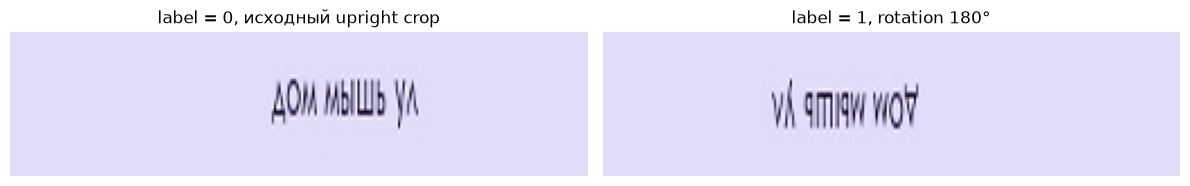

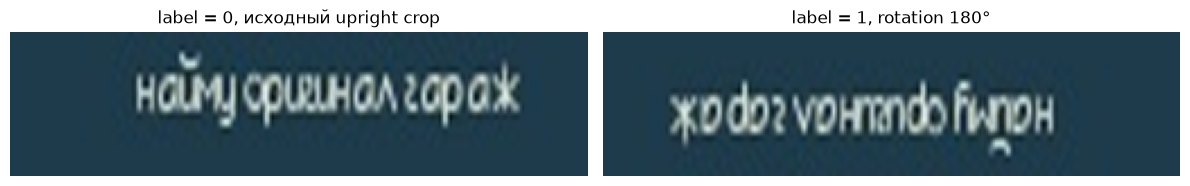

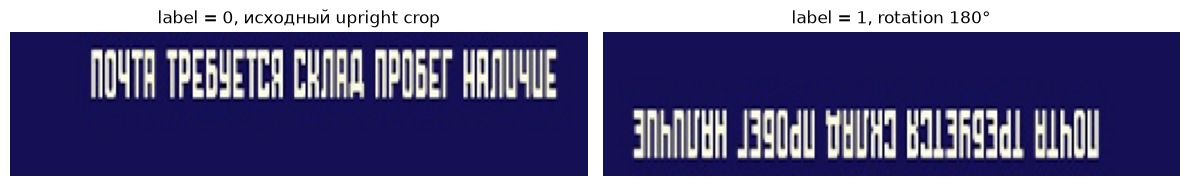

In [147]:
def show_dataset_pair(dataset, idx: int = 0):
    row = dataset.df.iloc[idx]

    image_bgr = cv2.imread(str(row["crop_path"]), cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    image_rot = cv2.rotate(image_rgb, cv2.ROTATE_180)

    image_0 = resize_keep_aspect_and_pad(image_rgb)
    image_1 = resize_keep_aspect_and_pad(image_rot)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    axes[0].imshow(image_0)
    axes[0].set_title("label = 0, исходный upright crop")
    axes[0].axis("off")

    axes[1].imshow(image_1)
    axes[1].set_title("label = 1, rotation 180°")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


show_dataset_pair(train_dataset, idx=0)
show_dataset_pair(train_dataset, idx=100)
show_dataset_pair(train_dataset, idx=500)

In [155]:
tiny_base_df = (
    data_df[(data_df["source"] == "synthetic_ru") & (data_df["split"] == "train")]
    .sample(n=64, random_state=SEED)
    .reset_index(drop=True)
)

tiny_0 = tiny_base_df.copy()
tiny_0["label_180"] = 0

tiny_1 = tiny_base_df.copy()
tiny_1["label_180"] = 1

tiny_eval_df = (
    pd.concat(
        [tiny_0, tiny_1],
        ignore_index=True,
    )
    .sample(
        frac=1.0,
        random_state=SEED,
    )
    .reset_index(drop=True)
)

print(tiny_eval_df["label_180"].value_counts())
assert len(tiny_eval_df) == 128
assert tiny_eval_df.groupby("crop_id")["label_180"].nunique().eq(2).all()

label_180
0    64
1    64
Name: count, dtype: int64


In [146]:
train_dataset.set_epoch(0)

labels_epoch0 = np.array(
    [train_dataset._get_label(i) for i in range(len(train_dataset))]
)

print("Train size:", len(train_dataset))
print("Label 0:", (labels_epoch0 == 0).sum())
print("Label 1:", (labels_epoch0 == 1).sum())
print("Share label=1:", labels_epoch0.mean())

assert 0.40 <= labels_epoch0.mean() <= 0.60

Train size: 17009
Label 0: 8404
Label 1: 8605
Share label=1: 0.5059086366041508


In [141]:
import torch.nn as nn
from torchvision.models import (
    mobilenet_v3_small,
    shufflenet_v2_x0_5,
)


def build_model(name: str, pretrained: bool = False) -> nn.Module:
    if name == "mobilenet_v3_small":
        model = mobilenet_v3_small(
            weights="DEFAULT" if pretrained else None,
        )
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, 1)

    elif name == "shufflenet_v2_x0_5":
        model = shufflenet_v2_x0_5(
            weights="DEFAULT" if pretrained else None,
        )
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 1)

    else:
        raise ValueError(f"Unknown model: {name}")

    return model


for model_name in ["mobilenet_v3_small", "shufflenet_v2_x0_5"]:
    model = build_model(model_name)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{model_name}: {n_params:,} parameters")

mobilenet_v3_small: 1,518,881 parameters
shufflenet_v2_x0_5: 342,817 parameters


In [142]:
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    roc_auc_score,
    log_loss,
)


@torch.no_grad()
def predict_loader(model, loader, device=DEVICE):
    model.eval()

    all_logits = []
    all_labels = []
    all_crop_ids = []
    all_sources = []

    for batch in loader:
        images = batch["image"].to(device)
        logits = model(images).flatten()

        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(batch["label"].numpy())
        all_crop_ids.extend(batch["crop_id"])
        all_sources.extend(batch["source"])

    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels).astype(int)
    probs = 1.0 / (1.0 + np.exp(-logits))

    return pd.DataFrame(
        {
            "crop_id": all_crop_ids,
            "source": all_sources,
            "label_180": labels,
            "logit": logits,
            "p_180": probs,
        }
    )


def metrics_from_predictions(pred_df: pd.DataFrame) -> dict:
    y = pred_df["label_180"].to_numpy(dtype=int)
    p = np.clip(pred_df["p_180"].to_numpy(dtype=float), 1e-7, 1 - 1e-7)
    y_hat = (p >= 0.5).astype(int)

    brier = brier_score_loss(y, p)

    return {
        "n": len(pred_df),
        "brier": brier,
        "1_minus_brier": 1.0 - brier,
        "accuracy": accuracy_score(y, y_hat),
        "roc_auc": roc_auc_score(y, p),
        "log_loss": log_loss(y, p, labels=[0, 1]),
    }

In [ ]:
import copy
from tqdm.auto import tqdm


def train_one_model(
    model_name: str,
    epochs: int = 12,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    pretrained: bool = False,
):
    model = build_model(
        name=model_name,
        pretrained=pretrained,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    criterion = nn.BCEWithLogitsLoss()

    best_state = None
    best_brier = float("inf")
    history = []

    for epoch in range(epochs):
        train_dataset.set_epoch(epoch)
        model.train()

        losses = []

        for batch in tqdm(
            train_loader,
            desc=f"{model_name} | epoch {epoch + 1}/{epochs}",
            leave=False,
        ):
            images = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images).flatten()
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        val_id_pred = predict_loader(model, val_id_loader)
        val_holdout_pred = predict_loader(model, cnn_holdout_eval_loader)

        val_id_metrics = metrics_from_predictions(val_id_pred)
        val_holdout_metrics = metrics_from_predictions(val_holdout_pred)

        row = {
            "epoch": epoch + 1,
            "train_loss": float(np.mean(losses)),
            **{f"val_id_{key}": value for key, value in val_id_metrics.items()},
            **{
                f"val_holdout_{key}": value
                for key, value in val_holdout_metrics.items()
            },
        }

        history.append(row)

        print(
            f"Epoch {epoch + 1:02d} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"val_id_brier={row['val_id_brier']:.4f} | "
            f"holdout_brier={row['val_holdout_brier']:.4f} | "
            f"holdout_acc={row['val_holdout_accuracy']:.4f}"
        )

        if val_holdout_metrics["brier"] < best_brier:
            best_brier = val_holdout_metrics["brier"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    best_val_id_pred = predict_loader(model, val_id_loader)
    best_val_holdout_pred = predict_loader(
        model,
        cnn_holdout_eval_loader,
    )

    history_df = pd.DataFrame(history)

    return {
        "model": model,
        "model_name": model_name,
        "best_brier_holdout": best_brier,
        "history": history_df,
        "val_id_pred": best_val_id_pred,
        "val_holdout_pred": best_val_holdout_pred,
        "val_id_metrics": metrics_from_predictions(best_val_id_pred),
        "val_holdout_metrics": metrics_from_predictions(best_val_holdout_pred),
    }

In [164]:
results = {}

results["mobilenet_v3_small"] = train_one_model(
    model_name="mobilenet_v3_small",
    epochs=30,
    lr=1e-4,
    pretrained=True,
)

results["shufflenet_v2_x0_5"] = train_one_model(
    model_name="shufflenet_v2_x0_5",
    epochs=30,
    lr=1e-4,
    pretrained=True,
)

Epoch 01 | train_loss=0.7122 | val_id_brier=0.2512 | holdout_brier=0.2443 | holdout_acc=0.5667


Epoch 02 | train_loss=0.6907 | val_id_brier=0.2517 | holdout_brier=0.2432 | holdout_acc=0.5573


Epoch 03 | train_loss=0.6729 | val_id_brier=0.2462 | holdout_brier=0.2427 | holdout_acc=0.5573


Epoch 04 | train_loss=0.6444 | val_id_brier=0.2400 | holdout_brier=0.2415 | holdout_acc=0.5733


Epoch 05 | train_loss=0.5973 | val_id_brier=0.2205 | holdout_brier=0.2288 | holdout_acc=0.6307


...

Epoch 26 | train_loss=0.3863 | val_id_brier=0.1824 | holdout_brier=0.2389 | holdout_acc=0.6187


Epoch 27 | train_loss=0.3782 | val_id_brier=0.1864 | holdout_brier=0.2422 | holdout_acc=0.6147


Epoch 28 | train_loss=0.3734 | val_id_brier=0.1859 | holdout_brier=0.2444 | holdout_acc=0.6240


Epoch 29 | train_loss=0.3646 | val_id_brier=0.1845 | holdout_brier=0.2425 | holdout_acc=0.6307


Epoch 30 | train_loss=0.3604 | val_id_brier=0.1892 | holdout_brier=0.2436 | holdout_acc=0.6320


#### 4.2.1. Результаты собственных CNN

Были протестированы две компактные архитектуры с ImageNet initialization:

- `MobileNetV3-Small`;
- `ShuffleNetV2 x0.5`.

Модели обучались с `BCEWithLogitsLoss`; основной критерий выбора checkpoint —
минимальный Brier score на отложенной real-image validation-выборке.

Эксперимент показал, что собственные CNN обучаются, однако на доступном объёме
внешних данных уступают специализированной PaddleOCR orientation-модели. Лучший
результат среди собственных архитектур показала MobileNetV3-Small, но её Brier
score остаётся выше результата PaddleOCR. Поэтому собственные CNN не выбраны
как итоговая production-модель.

### 4.3. Итоговое сравнение PaddleOCR и собственных CNN

Сравнение выполняется на одном и том же `val_holdout`-протоколе (4.1), поэтому
Brier score моделей ниже напрямую сопоставим.


In [145]:
comparison_rows = [
    {
        "model": "PaddleOCR",
        **paddle_metrics,
    }
]

for name, result in results.items():
    comparison_rows.append(
        {
            "model": name,
            **result["val_holdout_metrics"],
        }
    )

comparison_df = (
    pd.DataFrame(comparison_rows).sort_values("brier").reset_index(drop=True)
)

display(comparison_df.round(6))
comparison_df.to_csv(
    OUTPUTS_DIR / "model_comparison.csv",
    index=False,
)

,model,n,brier,1_minus_brier,accuracy,roc_auc,log_loss,mean_p_180,mean_p_180_label0,mean_p_180_label1
0,PaddleOCR,1500,0.156435,0.843565,0.793333,0.911269,0.587406,0.36874,0.085485,0.651994
1,shufflenet_v2_x0_5,750,0.248826,0.751174,0.508000,0.539516,0.690793,NaN,NaN,NaN
2,mobilenet_v3_small,750,0.249594,0.750406,0.496000,0.511314,0.692335,NaN,NaN,NaN


## 5. Основная модель: PaddleOCR text-line orientation classifier

В качестве основной модели используется открытый специализированный классификатор
ориентации текстовых строк `PP-LCNet_x0_25_textline_ori` из PaddleOCR/PaddleX.
Модель решает именно бинарную задачу определения направления текстовой строки:
$0^\circ$ или $180^\circ$.

Для каждого изображения модель возвращает класс и confidence предсказанного
класса. В submission требуется вероятность именно класса \(180^\circ\), поэтому
применяется преобразование:

$$
p_{180} =
\begin{cases}
s, & \text{если предсказан класс } 180^\circ; \\
1-s, & \text{если предсказан класс } 0^\circ,
\end{cases}
$$

где $s$ — confidence, возвращаемый классификатором.

In [170]:
def preprocess_for_paddle(
    image_bgr: np.ndarray,
    mode: str = "original",
) -> np.ndarray:
    """
    Возвращает BGR изображение для Paddle.
    Не меняет ориентацию, не делает resize к фиксированному размеру.
    """
    if mode == "original":
        return image_bgr

    if mode == "clahe":
        lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=1.5,
            tileGridSize=(8, 8),
        )

        l = clahe.apply(l)

        return cv2.cvtColor(
            cv2.merge([l, a, b]),
            cv2.COLOR_LAB2BGR,
        )

    if mode == "unsharp":
        blurred = cv2.GaussianBlur(
            image_bgr,
            (0, 0),
            sigmaX=1.0,
        )

        return cv2.addWeighted(
            image_bgr,
            1.20,
            blurred,
            -0.20,
            0,
        )

    if mode == "upscale_small":
        h, w = image_bgr.shape[:2]

        if h < 32:
            scale = min(2.0, 32.0 / max(h, 1))
            image_bgr = cv2.resize(
                image_bgr,
                (
                    max(1, int(round(w * scale))),
                    max(1, int(round(h * scale))),
                ),
                interpolation=cv2.INTER_CUBIC,
            )

        return image_bgr

    if mode == "morph_close":
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

        # Очень мягкая операция 2×2 — не использовать 3×3/5×5.
        kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT,
            (2, 2),
        )

        gray = cv2.morphologyEx(
            gray,
            cv2.MORPH_CLOSE,
            kernel,
            iterations=1,
        )

        return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    raise ValueError(f"Unknown preprocessing mode: {mode}")

### 5.1. Подбор preprocessing

Для повышения устойчивости к низкому контрасту и деградациям изображений были
сравнены несколько мягких методов preprocessing:

- исходное RGB-изображение;
- CLAHE по каналу яркости в пространстве LAB;
- unsharp mask;
- увеличение малых изображений;
- мягкое morphological closing.

Все варианты оценивались на одной и той же случайно зафиксированной подвыборке
из 400 парных validation-примеров. Выбор делался исключительно по Brier score.


In [171]:
PADDLE_PREPROCESS_MODES = [
    "original",
    "clahe",
    "unsharp",
    "upscale_small",
    "morph_close",
]
import tempfile
import time
from tqdm.auto import tqdm


def evaluate_paddle_preprocessing(
    model,
    eval_df: pd.DataFrame,
    mode: str,
) -> pd.DataFrame:
    records = []

    with tempfile.TemporaryDirectory() as tmp:
        tmp_dir = Path(tmp)

        for i, row in tqdm(
            eval_df.iterrows(),
            total=len(eval_df),
            desc=f"Paddle: {mode}",
        ):
            image_bgr = cv2.imread(
                str(row["crop_path"]),
                cv2.IMREAD_COLOR,
            )

            if image_bgr is None:
                raise FileNotFoundError(row["crop_path"])

            if int(row["label_180"]) == 1:
                image_bgr = cv2.rotate(
                    image_bgr,
                    cv2.ROTATE_180,
                )

            image_bgr = preprocess_for_paddle(
                image_bgr,
                mode=mode,
            )

            temp_path = tmp_dir / f"{i:07d}.jpg"

            ok = cv2.imwrite(
                str(temp_path),
                image_bgr,
                [int(cv2.IMWRITE_JPEG_QUALITY), 100],
            )

            if not ok:
                raise RuntimeError(f"Не удалось записать {temp_path}")

            result = list(
                model.predict(
                    input=str(temp_path),
                    batch_size=1,
                )
            )[0]

            p_180 = extract_paddle_p180(result)

            records.append(
                {
                    "eval_id": row["eval_id"],
                    "crop_id": row["crop_id"],
                    "label_180": int(row["label_180"]),
                    "p_180": p_180,
                    "preprocess": mode,
                }
            )

    return pd.DataFrame(records)

In [172]:
paddle_tuning_df = paddle_eval_df.sample(
    n=min(400, len(paddle_eval_df)), random_state=SEED
).reset_index(drop=True)

preprocess_results = []

for mode in PADDLE_PREPROCESS_MODES:
    pred_df = evaluate_paddle_preprocessing(
        model=paddle_model,
        eval_df=paddle_tuning_df,
        mode=mode,
    )

    metrics = compute_orientation_metrics(pred_df)

    preprocess_results.append(
        {
            "preprocess": mode,
            **metrics,
        }
    )

preprocess_comparison_df = (
    pd.DataFrame(preprocess_results).sort_values("brier").reset_index(drop=True)
)

display(preprocess_comparison_df.round(6))

Paddle: morph_close: 100%|██████████| 400/400 [00:01<00:00, 251.78it/s]


,preprocess,n,brier,1_minus_brier,accuracy,roc_auc,log_loss,mean_p_180,mean_p_180_label0,mean_p_180_label1
0,clahe,400,0.124983,0.875017,0.8275,0.915324,0.413096,0.514146,0.220405,0.826056
1,unsharp,400,0.145744,0.854256,0.8200,0.906741,0.570651,0.377620,0.093896,0.678893
2,original,400,0.154089,0.845911,0.8100,0.905928,0.631586,0.348349,0.070351,0.643543
3,upscale_small,400,0.161704,0.838296,0.8000,0.905890,0.701508,0.332923,0.060990,0.621675
4,morph_close,400,0.182118,0.817882,0.7775,0.889801,0.805575,0.304584,0.052914,0.571822


На validation-подвыборке наилучший результат показал CLAHE:

- Brier score: **0.1250**;
- \(1-\text{Brier}\): **0.8750**;
- accuracy: **0.8275**;
- ROC-AUC: **0.9153**.

По сравнению с исходным изображением Brier score уменьшился с 0.1541 до 0.1250.
Морфологическое закрытие, напротив, ухудшило качество до 0.1821, поэтому в
финальный pipeline не включается. В итоговом inference используется CLAHE по
L-каналу LAB-пространства.

## 6. Финальный inference и формирование `submission.csv`

Финальный pipeline применяется ко всем 20 000 тестовым изображениям:

1. изображение считывается в BGR/RGB-представлении;
2. применяется CLAHE к L-каналу LAB-пространства;
3. полученное изображение подаётся в PaddleOCR orientation classifier;
4. class confidence преобразуется в вероятность \(p_{180}\);
5. формируется файл `submission.csv` в порядке `sample_submission.csv`.

Перед сохранением выполняются проверки:

- число строк равно 20 000;
- присутствуют только колонки `image_id` и `p_180`;
- все `image_id` уникальны и совпадают с `sample_submission.csv`;
- все вероятности принадлежат отрезку \([0, 1]\);
- отсутствуют пропуски и некорректные численные значения.

In [ ]:
import time
from tqdm.auto import tqdm
from paddlex import create_model

paddle_model = create_model(model_name="PP-LCNet_x0_25_textline_ori")

def extract_paddle_p180(result) -> float:
    """
    Возвращает вероятность p_180 из результата PaddleX/PaddleOCR
    text-line orientation classifier.

    score = confidence предсказанного класса:
    - class_id == 1 / label_name == '180' -> p_180 = score;
    - class_id == 0 / label_name == '0'   -> p_180 = 1 - score.
    """
    if hasattr(result, "json"):
        result = result.json

    if isinstance(result, dict) and "res" in result:
        result = result["res"]

    class_ids = np.asarray(result["class_ids"]).reshape(-1)
    scores = np.asarray(result["scores"]).reshape(-1)

    class_id = int(class_ids[0])
    score = float(scores[0])

    if class_id == 1:
        p_180 = score
    elif class_id == 0:
        p_180 = 1.0 - score
    else:
        raise ValueError(
            f"Неожиданный class_id={class_id}. "
            f"Доступные данные результата: {result}"
        )

    return float(np.clip(p_180, 0.0, 1.0))


test_submit_df = pd.DataFrame(
    {
        "image_id": [p.stem for p in test_files],
        "image_path": [str(p) for p in test_files],
    }
)

# Критично: привести порядок к sample_submission.csv.
test_submit_df = sample_sub[["image_id"]].merge(
    test_submit_df, on="image_id", how="left", validate="one_to_one"
)

assert len(test_submit_df) == len(sample_sub) == 20_000
assert test_submit_df["image_path"].notna().all()

display(test_submit_df.head())

In [ ]:
import shutil
import time
from tqdm.auto import tqdm

PADDLE_BATCH_SIZE = 32
PADDLE_PREPROCESS = "clahe"

PADDLE_TMP_DIR = PROCESSED_DIR / "test_clahe_for_paddle"

if PADDLE_TMP_DIR.exists():
    shutil.rmtree(PADDLE_TMP_DIR)

PADDLE_TMP_DIR.mkdir(parents=True, exist_ok=True)


def preprocess_for_paddle(
    image_bgr: np.ndarray,
    mode: str = "clahe",
) -> np.ndarray:
    """
    Мягкий preprocessing для Paddle orientation classifier.
    Для финального решения выбран CLAHE по L-каналу в LAB.
    """
    if mode == "original":
        return image_bgr

    if mode == "clahe":
        lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=1.5,
            tileGridSize=(8, 8),
        )

        l_channel = clahe.apply(l_channel)

        return cv2.cvtColor(
            cv2.merge([l_channel, a_channel, b_channel]),
            cv2.COLOR_LAB2BGR,
        )

    raise ValueError(f"Unknown preprocessing mode: {mode}")

In [ ]:
preprocessed_paths = []

start_preprocess = time.perf_counter()

for image_id, image_path in tqdm(
    zip(
        test_submit_df["image_id"],
        test_submit_df["image_path"],
    ),
    total=len(test_submit_df),
    desc="Applying CLAHE to test images",
):
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise FileNotFoundError(f"Не удалось прочитать {image_path}")

    processed_bgr = preprocess_for_paddle(
        image_bgr,
        mode=PADDLE_PREPROCESS,
    )

    output_path = PADDLE_TMP_DIR / f"{image_id}.jpg"

    ok = cv2.imwrite(
        str(output_path),
        processed_bgr,
        [int(cv2.IMWRITE_JPEG_QUALITY), 100],
    )

    if not ok:
        raise RuntimeError(f"Не удалось сохранить {output_path}")

    preprocessed_paths.append(str(output_path))

elapsed_preprocess = time.perf_counter() - start_preprocess

assert len(preprocessed_paths) == len(test_submit_df)

print(f"CLAHE preprocessing: {elapsed_preprocess:.2f} sec")
print(
    f"Preprocessing speed: "
    f"{len(preprocessed_paths) / elapsed_preprocess:.2f} images/sec"
)

Applying CLAHE to test images: 100%|██████████| 20000/20000 [00:20<00:00, 995.68it/s] 

CLAHE preprocessing: 20.09 sec
Preprocessing speed: 995.62 images/sec


In [ ]:
start_inference = time.perf_counter()

raw_results = list(
    paddle_model.predict(
        input=preprocessed_paths,
        batch_size=PADDLE_BATCH_SIZE,
    )
)

elapsed_inference = time.perf_counter() - start_inference

assert len(raw_results) == len(test_submit_df), (
    f"Получено результатов: {len(raw_results)}, " f"ожидалось: {len(test_submit_df)}"
)

p180_values = np.asarray(
    [
        extract_paddle_p180(result)
        for result in tqdm(raw_results, desc="Extracting p_180")
    ],
    dtype=np.float64,
)

print(f"\nВсего обработано: {len(p180_values)}")
print(f"Inference: {elapsed_inference:.2f} sec")
print(f"Inference speed: " f"{len(p180_values) / elapsed_inference:.2f} images/sec")
print(f"Inference time/image: " f"{1000 * elapsed_inference / len(p180_values):.2f} ms")
print(f"End-to-end time: " f"{elapsed_preprocess + elapsed_inference:.2f} sec")

Extracting p_180: 100%|██████████| 20000/20000 [00:02<00:00, 8501.13it/s]


Всего обработано: 20000
Inference: 72.34 sec
Inference speed: 276.48 images/sec
Inference time/image: 3.62 ms
End-to-end time: 92.42 sec


In [ ]:
submission_paddle = pd.DataFrame(
    {
        "image_id": test_submit_df["image_id"],
        "p_180": np.asarray(p180_values, dtype=np.float64),
    }
)

# Проверки формата.
assert list(submission_paddle.columns) == ["image_id", "p_180"]
assert len(submission_paddle) == 20_000
assert submission_paddle["image_id"].is_unique
assert submission_paddle["image_id"].equals(sample_sub["image_id"])
assert submission_paddle["p_180"].notna().all()
assert submission_paddle["p_180"].between(0.0, 1.0).all()

output_path = OUTPUTS_DIR / "submission_paddle.csv"

submission_paddle.to_csv(
    output_path,
    index=False,
    float_format="%.8f",
)

print(f"Сохранён файл: {output_path}")
display(submission_paddle.head())
display(submission_paddle["p_180"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

Сохранён файл: /Users/vika/Projects/classifier_rotation/outputs/submission_paddle.csv


,image_id,p_180
0,test_00000,0.62715
1,test_00001,0.99993
2,test_00002,0.99998
3,test_00003,0.53685
4,test_00004,0.99988


count    20000.000000
mean         0.575182
std          0.431499
min          0.000000
1%           0.000010
5%           0.000170
50%          0.779510
95%          0.999930
99%          1.000000
max          1.000000
Name: p_180, dtype: float64

## 7. Итоги и ограничения

### Итоговое решение

В работе реализован воспроизводимый pipeline классификации ориентации текстовых
кропов \(0^\circ/180^\circ\) с вероятностным выходом \(p_{180}\).

Итоговый pipeline использует:

1. мягкое усиление локального контраста CLAHE по каналу яркости;
2. специализированный text-line orientation classifier
   `PP-LCNet_x0_25_textline_ori` из PaddleOCR/PaddleX;
3. преобразование confidence предсказанного класса в вероятность \(p_{180}\);
4. формирование submission строго в формате исходного шаблона.

### Проведённые эксперименты

- Выполнен аудит 20 000 test-кропов: все изображения корректно считываются,
  имеют RGB-формат и согласованные идентификаторы.
- Подготовлена внешняя обучающая выборка из 5 006 отфильтрованных реальных
  COCO-кропов и 15 000 синтетических русско-английских текстовых изображений.
- Реализованы и сравнены компактные CNN MobileNetV3-Small и ShuffleNetV2 x0.5.
- Наиболее сильной собственной моделью стала MobileNetV3-Small с Brier score
  0.2253 на holdout-validation.
- Специализированный PaddleOCR baseline показал Brier score 0.1564 и был выбран
  как основная модель.
- На фиксированной tuning subset CLAHE дополнительно улучшил Brier score
  с 0.1541 до 0.1250.

### Ограничения

Внешняя validation-выборка основана на COCO-кропах и не полностью совпадает с
закрытым доменом изображений объявлений. Поэтому итоговая оценка на тестовой
выборке может отличаться от offline-оценки. Для дальнейшего улучшения наиболее
перспективны расширение real-image данных с русскоязычным текстом, калибровка
вероятностей на независимой внешней validation-выборке и проверка ансамбля
PaddleOCR с собственной MobileNetV3.